In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import json
from pathlib import Path

print("xarray version :", xr.__version__)
print("numpy version  :", np.__version__)
print("pandas version :", pd.__version__)

print("\nLibraries loaded successfully.")

xarray version : 2025.12.0
numpy version  : 2.1.3
pandas version : 2.2.3

Libraries loaded successfully.


In [2]:
import zipfile
from pathlib import Path

print("=" * 70)
print("EXTRACTING PROCESSED OCEANEMBED DATA")
print("=" * 70)

# ZIP file manually uploaded to /content
zip_files = list(Path("/content").glob("*.zip"))

if not zip_files:
    raise FileNotFoundError(
        "❌ No ZIP file found in /content. "
        "Upload processed_oceanembed.zip using the Colab Files panel first."
    )

# Use the first ZIP file found
zip_path = zip_files[0]

print(f"\nZIP file found: {zip_path.name}")

# Extract
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("✅ ZIP extracted successfully.")



EXTRACTING PROCESSED OCEANEMBED DATA

ZIP file found: processed_oceanembed.zip
✅ ZIP extracted successfully.


In [3]:
from pathlib import Path
import shutil

print("=" * 70)
print("ORGANIZING PROCESSED OCEANEMBED DATA")
print("=" * 70)

# Destination folder
processed_dir = Path("/content/processed_oceanembed")
processed_dir.mkdir(exist_ok=True)

# Files that should be inside the processed folder
required_files = [
    "common_ocean_mask.npy",
    "depths.npy",
    "latitude.npy",
    "longitude.npy",
    "metadata.json",
    "processed_data.nc",
    "time.npy",
    "valid_patch_centers.npy"
]

print("\nMoving extracted files...")

for filename in required_files:
    source = Path("/content") / filename
    destination = processed_dir / filename

    if source.exists():
        # Move only if it is not already in the destination
        if not destination.exists():
            shutil.move(str(source), str(destination))
            print(f"  ✅ Moved: {filename}")
        else:
            print(f"  ℹ️ Already exists: {filename}")
    else:
        print(f"  ⚠️ Not found: {filename}")

# ---------------------------------------------------------
# Verify final folder
# ---------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL PROCESSED FOLDER")
print("-" * 70)

if processed_dir.exists():
    for file in sorted(processed_dir.iterdir()):
        size_mb = file.stat().st_size / (1024 ** 2)
        print(f"  ✅ {file.name:30s} {size_mb:.2f} MB")

print("\nProcessed directory:")
print(processed_dir)

print("\n" + "=" * 70)
print("ORGANIZATION COMPLETE")
print("=" * 70)

ORGANIZING PROCESSED OCEANEMBED DATA

Moving extracted files...
  ✅ Moved: common_ocean_mask.npy
  ✅ Moved: depths.npy
  ✅ Moved: latitude.npy
  ✅ Moved: longitude.npy
  ✅ Moved: metadata.json
  ✅ Moved: processed_data.nc
  ✅ Moved: time.npy
  ✅ Moved: valid_patch_centers.npy

----------------------------------------------------------------------
FINAL PROCESSED FOLDER
----------------------------------------------------------------------
  ✅ common_ocean_mask.npy          0.02 MB
  ✅ depths.npy                     0.00 MB
  ✅ latitude.npy                   0.00 MB
  ✅ longitude.npy                  0.00 MB
  ✅ metadata.json                  0.00 MB
  ✅ processed_data.nc              279.55 MB
  ✅ time.npy                       0.00 MB
  ✅ valid_patch_centers.npy        0.06 MB

Processed directory:
/content/processed_oceanembed

ORGANIZATION COMPLETE


In [4]:
import xarray as xr

print("=" * 70)
print("LOADING PROCESSED OCEANEMBED DATA")
print("=" * 70)

# Path to saved processed dataset
processed_file = processed_dir / "processed_data.nc"

# Open dataset
processed_data = xr.open_dataset(processed_file)

print("\n✅ Dataset loaded successfully!")

print("\nDataset summary:")
print(processed_data)

print("\n" + "-" * 70)
print("AVAILABLE VARIABLES")
print("-" * 70)

for name in processed_data.data_vars:
    print(f"  ✅ {name}")

print("\n" + "=" * 70)
print("DATASET LOADING COMPLETE")
print("=" * 70)

LOADING PROCESSED OCEANEMBED DATA

✅ Dataset loaded successfully!

Dataset summary:
<xarray.Dataset> Size: 874MB
Dimensions:    (time: 455, latitude: 100, longitude: 240, depth: 15)
Coordinates:
  * time       (time) datetime64[ns] 4kB 2025-01-01 2025-01-02 ... 2026-03-31
  * latitude   (latitude) float64 800B 5.125 5.375 5.625 ... 29.38 29.62 29.88
  * longitude  (longitude) float64 2kB 45.12 45.38 45.62 ... 104.4 104.6 104.9
  * depth      (depth) float64 120B 0.0 5.0 10.0 20.0 ... 500.0 700.0 1e+03
Data variables:
    SST        (time, latitude, longitude) float32 44MB ...
    SSS        (time, latitude, longitude) float32 44MB ...
    SLA        (time, latitude, longitude) float32 44MB ...
    U          (time, latitude, longitude) float32 44MB ...
    V          (time, latitude, longitude) float32 44MB ...
    thetao     (time, depth, latitude, longitude) float32 655MB ...
Attributes:
    project:                 OceanEmbed
    grid_resolution:         0.25 degree
    patch_size: 

In [5]:
import numpy as np
import json

print("=" * 70)
print("LOADING SAVED PATCH INFORMATION")
print("=" * 70)

# ---------------------------------------------------------
# Load common ocean mask
# ---------------------------------------------------------
common_ocean_mask = np.load(
    processed_dir / "common_ocean_mask.npy"
).astype(bool)

# ---------------------------------------------------------
# Load valid patch centers
# ---------------------------------------------------------
valid_patch_centers = np.load(
    processed_dir / "valid_patch_centers.npy"
)

# ---------------------------------------------------------
# Load coordinates
# ---------------------------------------------------------
latitude = np.load(
    processed_dir / "latitude.npy"
)

longitude = np.load(
    processed_dir / "longitude.npy"
)

depths = np.load(
    processed_dir / "depths.npy"
)

time = np.load(
    processed_dir / "time.npy"
)

# ---------------------------------------------------------
# Load metadata
# ---------------------------------------------------------
with open(processed_dir / "metadata.json", "r") as f:
    metadata = json.load(f)

# ---------------------------------------------------------
# Display information
# ---------------------------------------------------------

print("\n✅ Common ocean mask loaded")
print(f"   Shape : {common_ocean_mask.shape}")
print(f"   Valid ocean cells : {common_ocean_mask.sum():,}")

print("\n✅ Valid patch centers loaded")
print(f"   Shape : {valid_patch_centers.shape}")
print(f"   Number of centers : {len(valid_patch_centers):,}")

print("\nFirst 5 patch centers:")
print(valid_patch_centers[:5])

print("\n✅ Coordinates loaded")
print(f"   Latitude  : {len(latitude)} values")
print(f"   Longitude : {len(longitude)} values")
print(f"   Depths    : {len(depths)} values")
print(f"   Time      : {len(time)} values")

print("\nTarget depths:")
print(depths)

print("\n✅ Metadata loaded")
print(json.dumps(metadata, indent=4))

print("\n" + "=" * 70)
print("PATCH INFORMATION LOADED SUCCESSFULLY")
print("=" * 70)

LOADING SAVED PATCH INFORMATION

✅ Common ocean mask loaded
   Shape : (100, 240)
   Valid ocean cells : 11,613

✅ Valid patch centers loaded
   Shape : (4996, 3)
   Number of centers : 4,996

First 5 patch centers:
[[16.         27.          0.7519531 ]
 [16.         28.          0.7763672 ]
 [16.         29.          0.80078125]
 [16.         30.          0.8251953 ]
 [16.         31.          0.8486328 ]]

✅ Coordinates loaded
   Latitude  : 100 values
   Longitude : 240 values
   Depths    : 15 values
   Time      : 455 values

Target depths:
[   0.    5.   10.   20.   30.   50.   75.  100.  125.  150.  200.  300.
  500.  700. 1000.]

✅ Metadata loaded
{
    "project": "OceanEmbed",
    "grid_resolution": "0.25 degree",
    "patch_size": "32x32",
    "patch_physical_size": "8x8 degrees",
    "minimum_ocean_coverage": 0.75,
    "input_channels": [
        "SST",
        "SSS",
        "SSH_SLA",
        "U_current",
        "V_current"
    ],
    "target": "GLORYS_thetao",
    "targ

In [6]:
print("=" * 70)
print("VERIFYING SAVED COORDINATES AND MASK")
print("=" * 70)

# ---------------------------------------------------------
# Compare saved coordinates with NetCDF coordinates
# ---------------------------------------------------------

lat_match = np.array_equal(
    latitude,
    processed_data.latitude.values
)

lon_match = np.array_equal(
    longitude,
    processed_data.longitude.values
)

depth_match = np.array_equal(
    depths,
    processed_data.depth.values
)

time_match = np.array_equal(
    time,
    processed_data.time.values
)

print("\nCoordinate checks:")
print(f"  Latitude  match : {lat_match}")
print(f"  Longitude match : {lon_match}")
print(f"  Depth     match : {depth_match}")
print(f"  Time      match : {time_match}")

# ---------------------------------------------------------
# Check mask shape
# ---------------------------------------------------------

print("\nMask:")
print(f"  Shape : {common_ocean_mask.shape}")
print(f"  Expected : (100, 240)")
print(f"  Ocean cells : {common_ocean_mask.sum():,}")

# ---------------------------------------------------------
# Check patch centers
# ---------------------------------------------------------

print("\nPatch centers:")
print(f"  Number of centers : {len(valid_patch_centers):,}")
print(f"  Expected          : 4,996")

# Check index ranges
lat_indices = valid_patch_centers[:, 0].astype(int)
lon_indices = valid_patch_centers[:, 1].astype(int)

print(f"  Latitude index range  : {lat_indices.min()} → {lat_indices.max()}")
print(f"  Longitude index range : {lon_indices.min()} → {lon_indices.max()}")

# ---------------------------------------------------------
# Check ocean coverage
# ---------------------------------------------------------

coverage = valid_patch_centers[:, 2]

print("\nPatch ocean coverage:")
print(f"  Minimum : {coverage.min():.2%}")
print(f"  Maximum : {coverage.max():.2%}")
print(f"  Mean    : {coverage.mean():.2%}")

# ---------------------------------------------------------
# Final status
# ---------------------------------------------------------

all_checks = (
    lat_match
    and lon_match
    and depth_match
    and time_match
    and common_ocean_mask.shape == (100, 240)
    and len(valid_patch_centers) == 4996
)

print("\n" + "=" * 70)

if all_checks:
    print("✅ ALL CHECKS PASSED")
else:
    print("❌ SOME CHECKS FAILED — STOP HERE")

print("=" * 70)

VERIFYING SAVED COORDINATES AND MASK

Coordinate checks:
  Latitude  match : True
  Longitude match : True
  Depth     match : True
  Time      match : True

Mask:
  Shape : (100, 240)
  Expected : (100, 240)
  Ocean cells : 11,613

Patch centers:
  Number of centers : 4,996
  Expected          : 4,996
  Latitude index range  : 16 → 72
  Longitude index range : 27 → 205

Patch ocean coverage:
  Minimum : 75.00%
  Maximum : 100.00%
  Mean    : 94.19%

✅ ALL CHECKS PASSED


In [7]:
print("=" * 70)
print("SETTING PATCH CONFIGURATION")
print("=" * 70)

# ---------------------------------------------------------
# Patch configuration
# ---------------------------------------------------------

PATCH_SIZE = 32
HALF_PATCH = PATCH_SIZE // 2

INPUT_VARIABLES = [
    "SST",
    "SSS",
    "SLA",
    "U",
    "V"
]

TARGET_VARIABLE = "thetao"

NUM_INPUT_CHANNELS = len(INPUT_VARIABLES)
NUM_TARGET_DEPTHS = len(depths)

# ---------------------------------------------------------
# Grid information
# ---------------------------------------------------------

NUM_LAT = len(latitude)
NUM_LON = len(longitude)

# Valid center indices must have a complete 32x32 patch
MIN_LAT_INDEX = HALF_PATCH
MAX_LAT_INDEX = NUM_LAT - HALF_PATCH

MIN_LON_INDEX = HALF_PATCH
MAX_LON_INDEX = NUM_LON - HALF_PATCH

# ---------------------------------------------------------
# Display configuration
# ---------------------------------------------------------

print("\nPatch configuration:")
print(f"  Patch size           : {PATCH_SIZE} × {PATCH_SIZE}")
print(f"  Half patch           : {HALF_PATCH}")
print(f"  Grid resolution      : 0.25°")
print(f"  Physical patch size  : {PATCH_SIZE * 0.25}° × {PATCH_SIZE * 0.25}°")

print("\nInput configuration:")
print(f"  Variables            : {INPUT_VARIABLES}")
print(f"  Number of channels   : {NUM_INPUT_CHANNELS}")

print("\nTarget configuration:")
print(f"  Variable             : {TARGET_VARIABLE}")
print(f"  Number of depths     : {NUM_TARGET_DEPTHS}")
print(f"  Depths (m)           : {depths.astype(int).tolist()}")

print("\nGrid:")
print(f"  Latitude cells       : {NUM_LAT}")
print(f"  Longitude cells      : {NUM_LON}")

print("\nValid center index range:")
print(f"  Latitude index       : {MIN_LAT_INDEX} → {MAX_LAT_INDEX - 1}")
print(f"  Longitude index      : {MIN_LON_INDEX} → {MAX_LON_INDEX - 1}")

print("\n" + "=" * 70)
print("PATCH CONFIGURATION READY")
print("=" * 70)

SETTING PATCH CONFIGURATION

Patch configuration:
  Patch size           : 32 × 32
  Half patch           : 16
  Grid resolution      : 0.25°
  Physical patch size  : 8.0° × 8.0°

Input configuration:
  Variables            : ['SST', 'SSS', 'SLA', 'U', 'V']
  Number of channels   : 5

Target configuration:
  Variable             : thetao
  Number of depths     : 15
  Depths (m)           : [0, 5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 300, 500, 700, 1000]

Grid:
  Latitude cells       : 100
  Longitude cells      : 240

Valid center index range:
  Latitude index       : 16 → 83
  Longitude index      : 16 → 223

PATCH CONFIGURATION READY


In [8]:
print("=" * 70)
print("CREATING PATCH EXTRACTION FUNCTION")
print("=" * 70)


def extract_patch(day_idx, lat_idx, lon_idx):
    """
    Extract one 32x32 surface patch and the
    15-depth GLORYS temperature profile at its center.

    Parameters
    ----------
    day_idx : int
        Time index.

    lat_idx : int
        Center latitude index.

    lon_idx : int
        Center longitude index.

    Returns
    -------
    X : np.ndarray
        Surface input patch.
        Shape: (32, 32, 5)

    y : np.ndarray
        GLORYS temperature profile.
        Shape: (15,)
    """

    # -----------------------------------------------------
    # Calculate patch boundaries
    # -----------------------------------------------------

    lat_start = lat_idx - HALF_PATCH
    lat_end = lat_idx + HALF_PATCH

    lon_start = lon_idx - HALF_PATCH
    lon_end = lon_idx + HALF_PATCH

    # -----------------------------------------------------
    # Extract the 5 input variables
    # -----------------------------------------------------

    patch_channels = []

    for variable in INPUT_VARIABLES:

        patch = processed_data[variable].isel(
            time=day_idx,
            latitude=slice(lat_start, lat_end),
            longitude=slice(lon_start, lon_end)
        ).values

        patch_channels.append(patch)

    # Stack the 5 channels
    X = np.stack(
        patch_channels,
        axis=-1
    ).astype(np.float32)

    # -----------------------------------------------------
    # Extract target temperature profile
    # at the patch center
    # -----------------------------------------------------

    y = processed_data[TARGET_VARIABLE].isel(
        time=day_idx,
        latitude=lat_idx,
        longitude=lon_idx
    ).values.astype(np.float32)

    return X, y


print("\n✅ Function created successfully.")

print("\nFunction:")
print("  extract_patch(day_idx, lat_idx, lon_idx)")

print("\nExpected output:")
print("  X → (32, 32, 5)")
print("  y → (15,)")

print("\n" + "=" * 70)
print("PATCH EXTRACTION FUNCTION READY")
print("=" * 70)

CREATING PATCH EXTRACTION FUNCTION

✅ Function created successfully.

Function:
  extract_patch(day_idx, lat_idx, lon_idx)

Expected output:
  X → (32, 32, 5)
  y → (15,)

PATCH EXTRACTION FUNCTION READY


In [9]:
print("=" * 70)
print("TESTING ONE 32×32 PATCH")
print("=" * 70)

# ---------------------------------------------------------
# Select the first valid patch center
# ---------------------------------------------------------

test_day = 0

test_lat_idx = int(valid_patch_centers[0, 0])
test_lon_idx = int(valid_patch_centers[0, 1])
test_coverage = float(valid_patch_centers[0, 2])

# ---------------------------------------------------------
# Extract patch
# ---------------------------------------------------------

X_test, y_test = extract_patch(
    day_idx=test_day,
    lat_idx=test_lat_idx,
    lon_idx=test_lon_idx
)

# ---------------------------------------------------------
# Get geographic coordinates
# ---------------------------------------------------------

center_lat = latitude[test_lat_idx]
center_lon = longitude[test_lon_idx]

# ---------------------------------------------------------
# Display information
# ---------------------------------------------------------

print("\nSample information:")
print(f"  Day index            : {test_day}")
print(f"  Date                 : {time[test_day]}")
print(f"  Center latitude      : {center_lat:.3f}°N")
print(f"  Center longitude     : {center_lon:.3f}°E")
print(f"  Ocean coverage       : {test_coverage:.2%}")

print("\nInput patch X:")
print(f"  Shape                : {X_test.shape}")
print(f"  Expected             : (32, 32, 5)")
print(f"  Data type            : {X_test.dtype}")
print(f"  Total values         : {X_test.size:,}")
print(f"  NaN count            : {np.isnan(X_test).sum()}")

print("\nTarget y:")
print(f"  Shape                : {y_test.shape}")
print(f"  Expected             : (15,)")
print(f"  Data type            : {y_test.dtype}")
print(f"  NaN count            : {np.isnan(y_test).sum()}")

print("\nTarget temperature profile:")

for depth, temperature in zip(depths, y_test):
    print(f"  {depth:6.0f} m : {temperature:.3f} °C")

# ---------------------------------------------------------
# Final checks
# ---------------------------------------------------------

shape_ok = X_test.shape == (32, 32, 5)
target_ok = y_test.shape == (15,)
input_nan_ok = not np.isnan(X_test).any()
target_nan_ok = not np.isnan(y_test).any()

print("\n" + "-" * 70)

if shape_ok and target_ok and input_nan_ok and target_nan_ok:
    print("✅ PATCH TEST PASSED")
else:
    print("❌ PATCH TEST FAILED")

print("-" * 70)
print("Expected: X=(32,32,5), y=(15,), no NaNs")
print("=" * 70)

TESTING ONE 32×32 PATCH

Sample information:
  Day index            : 0
  Date                 : 2025-01-01T00:00:00.000000000
  Center latitude      : 9.125°N
  Center longitude     : 51.875°E
  Ocean coverage       : 75.20%

Input patch X:
  Shape                : (32, 32, 5)
  Expected             : (32, 32, 5)
  Data type            : float32
  Total values         : 5,120
  NaN count            : 1204

Target y:
  Shape                : (15,)
  Expected             : (15,)
  Data type            : float32
  NaN count            : 0

Target temperature profile:
       0 m : 26.177 °C
       5 m : 26.173 °C
      10 m : 26.164 °C
      20 m : 26.154 °C
      30 m : 26.148 °C
      50 m : 26.144 °C
      75 m : 26.085 °C
     100 m : 24.287 °C
     125 m : 21.811 °C
     150 m : 19.380 °C
     200 m : 15.920 °C
     300 m : 13.201 °C
     500 m : 11.460 °C
     700 m : 10.063 °C
    1000 m : 7.589 °C

----------------------------------------------------------------------
❌ PATCH TEST

In [10]:
print("=" * 70)
print("ANALYZING NaN VALUES IN THE INPUT PATCH")
print("=" * 70)

print("\nNaN count by input variable:")

for i, variable in enumerate(INPUT_VARIABLES):
    nan_count = np.isnan(X_test[:, :, i]).sum()
    total_count = X_test[:, :, i].size
    valid_count = total_count - nan_count

    print(
        f"  {variable:5s} : "
        f"NaN = {nan_count:4d} | "
        f"Valid = {valid_count:4d} | "
        f"Valid % = {valid_count / total_count:.2%}"
    )

print("\n" + "-" * 70)

total_nan = np.isnan(X_test).sum()
total_values = X_test.size

print(f"Total values : {total_values:,}")
print(f"Total NaNs   : {total_nan:,}")
print(f"Valid values : {total_values - total_nan:,}")
print(f"Valid %      : {(total_values - total_nan) / total_values:.2%}")

print("\n" + "-" * 70)

# Check whether all variables have the same land pattern
nan_masks = [
    np.isnan(X_test[:, :, i])
    for i in range(NUM_INPUT_CHANNELS)
]

same_nan_mask = all(
    np.array_equal(nan_masks[0], mask)
    for mask in nan_masks[1:]
)

print(f"Same land/NaN pattern across all 5 inputs: {same_nan_mask}")

print("\n" + "=" * 70)
print("NaN ANALYSIS COMPLETE")
print("=" * 70)

ANALYZING NaN VALUES IN THE INPUT PATCH

NaN count by input variable:
  SST   : NaN =  243 | Valid =  781 | Valid % = 76.27%
  SSS   : NaN =  250 | Valid =  774 | Valid % = 75.59%
  SLA   : NaN =  241 | Valid =  783 | Valid % = 76.46%
  U     : NaN =  235 | Valid =  789 | Valid % = 77.05%
  V     : NaN =  235 | Valid =  789 | Valid % = 77.05%

----------------------------------------------------------------------
Total values : 5,120
Total NaNs   : 1,204
Valid values : 3,916
Valid %      : 76.48%

----------------------------------------------------------------------
Same land/NaN pattern across all 5 inputs: False

NaN ANALYSIS COMPLETE


In [11]:
print("=" * 70)
print("CREATING CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT")
print("=" * 70)

NUM_DAYS = len(time)

# ---------------------------------------------------------
# Chronological split
# ---------------------------------------------------------

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

train_end = int(NUM_DAYS * TRAIN_RATIO)
val_end = int(NUM_DAYS * (TRAIN_RATIO + VAL_RATIO))

train_indices = np.arange(0, train_end)
val_indices = np.arange(train_end, val_end)
test_indices = np.arange(val_end, NUM_DAYS)

# ---------------------------------------------------------
# Display split information
# ---------------------------------------------------------

print("\nTotal days:")
print(f"  {NUM_DAYS}")

print("\nSplit sizes:")
print(f"  Training   : {len(train_indices)} days")
print(f"  Validation : {len(val_indices)} days")
print(f"  Testing    : {len(test_indices)} days")

print("\nDate ranges:")

print(
    f"  Training   : "
    f"{time[train_indices[0]]} → {time[train_indices[-1]]}"
)

print(
    f"  Validation : "
    f"{time[val_indices[0]]} → {time[val_indices[-1]]}"
)

print(
    f"  Testing    : "
    f"{time[test_indices[0]]} → {time[test_indices[-1]]}"
)

print("\nIndex ranges:")

print(
    f"  Training   : "
    f"{train_indices[0]} → {train_indices[-1]}"
)

print(
    f"  Validation : "
    f"{val_indices[0]} → {val_indices[-1]}"
)

print(
    f"  Testing    : "
    f"{test_indices[0]} → {test_indices[-1]}"
)

# ---------------------------------------------------------
# Check for overlap
# ---------------------------------------------------------

train_val_overlap = np.intersect1d(
    train_indices,
    val_indices
)

train_test_overlap = np.intersect1d(
    train_indices,
    test_indices
)

val_test_overlap = np.intersect1d(
    val_indices,
    test_indices
)

print("\nOverlap checks:")
print(f"  Train ↔ Validation : {len(train_val_overlap)}")
print(f"  Train ↔ Test       : {len(train_test_overlap)}")
print(f"  Validation ↔ Test  : {len(val_test_overlap)}")

if (
    len(train_val_overlap) == 0
    and len(train_test_overlap) == 0
    and len(val_test_overlap) == 0
):
    print("\n✅ No temporal overlap — split is clean.")
else:
    print("\n❌ Temporal overlap detected.")

print("\n" + "=" * 70)
print("TIME SPLIT COMPLETE")
print("=" * 70)

CREATING CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT

Total days:
  455

Split sizes:
  Training   : 318 days
  Validation : 68 days
  Testing    : 69 days

Date ranges:
  Training   : 2025-01-01T00:00:00.000000000 → 2025-11-14T00:00:00.000000000
  Validation : 2025-11-15T00:00:00.000000000 → 2026-01-21T00:00:00.000000000
  Testing    : 2026-01-22T00:00:00.000000000 → 2026-03-31T00:00:00.000000000

Index ranges:
  Training   : 0 → 317
  Validation : 318 → 385
  Testing    : 386 → 454

Overlap checks:
  Train ↔ Validation : 0
  Train ↔ Test       : 0
  Validation ↔ Test  : 0

✅ No temporal overlap — split is clean.

TIME SPLIT COMPLETE


In [12]:
print("=" * 70)
print("CALCULATING TRAINING-ONLY NORMALIZATION STATISTICS")
print("=" * 70)

# ---------------------------------------------------------
# Calculate mean and standard deviation for each input
# using ONLY the training period
# ---------------------------------------------------------

normalization_stats = {}

print("\nCalculating statistics...")

for variable in INPUT_VARIABLES:

    data = processed_data[variable].isel(
        time=train_indices
    ).values.astype(np.float32)

    # Ignore NaN land/missing values
    mean_value = np.nanmean(data)
    std_value = np.nanstd(data)

    normalization_stats[variable] = {
        "mean": float(mean_value),
        "std": float(std_value)
    }

    print(
        f"  {variable:5s} → "
        f"mean = {mean_value:.6f}, "
        f"std = {std_value:.6f}"
    )

print("\n" + "-" * 70)

# ---------------------------------------------------------
# Check that standard deviations are valid
# ---------------------------------------------------------

all_valid = all(
    stats["std"] > 0
    for stats in normalization_stats.values()
)

print(f"All standard deviations > 0 : {all_valid}")

# ---------------------------------------------------------
# Display final statistics
# ---------------------------------------------------------

print("\nNormalization statistics:")
print(json.dumps(normalization_stats, indent=4))

print("\n" + "=" * 70)

if all_valid:
    print("✅ TRAINING NORMALIZATION STATISTICS READY")
else:
    print("❌ INVALID STANDARD DEVIATION DETECTED")

print("=" * 70)

CALCULATING TRAINING-ONLY NORMALIZATION STATISTICS

Calculating statistics...
  SST   → mean = 28.515554, std = 1.887304
  SSS   → mean = 34.604740, std = 2.037591
  SLA   → mean = 0.148192, std = 0.104537
  U     → mean = 0.064247, std = 0.286490
  V     → mean = 0.005182, std = 0.237721

----------------------------------------------------------------------
All standard deviations > 0 : True

Normalization statistics:
{
    "SST": {
        "mean": 28.515554428100586,
        "std": 1.8873037099838257
    },
    "SSS": {
        "mean": 34.604740142822266,
        "std": 2.0375914573669434
    },
    "SLA": {
        "mean": 0.14819228649139404,
        "std": 0.10453727841377258
    },
    "U": {
        "mean": 0.06424664705991745,
        "std": 0.28648972511291504
    },
    "V": {
        "mean": 0.005181537009775639,
        "std": 0.23772144317626953
    }
}

✅ TRAINING NORMALIZATION STATISTICS READY


In [13]:
print("=" * 70)
print("CREATING INPUT NORMALIZATION FUNCTION")
print("=" * 70)


def normalize_input_patch(X):
    """
    Normalize a surface input patch using
    training-only statistics.

    Input:
        X shape = (32, 32, 5)

    Output:
        Normalized X shape = (32, 32, 5)

    NaN values are replaced with 0 after normalization.
    """

    X_normalized = np.empty_like(X, dtype=np.float32)

    for channel, variable in enumerate(INPUT_VARIABLES):

        mean_value = normalization_stats[variable]["mean"]
        std_value = normalization_stats[variable]["std"]

        X_normalized[:, :, channel] = (
            X[:, :, channel] - mean_value
        ) / std_value

    # Replace land/missing-data NaNs
    # 0 represents the normalized training mean
    X_normalized = np.nan_to_num(
        X_normalized,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return X_normalized


print("\n✅ Normalization function created.")

print("\nFunction:")
print("  normalize_input_patch(X)")

print("\nNormalization:")
print("  X_normalized = (X - training_mean) / training_std")

print("\nNaN handling:")
print("  NaN → 0.0 after normalization")

print("\nExpected:")
print("  Input  → (32, 32, 5)")
print("  Output → (32, 32, 5)")

print("\n" + "=" * 70)
print("NORMALIZATION FUNCTION READY")
print("=" * 70)

CREATING INPUT NORMALIZATION FUNCTION

✅ Normalization function created.

Function:
  normalize_input_patch(X)

Normalization:
  X_normalized = (X - training_mean) / training_std

NaN handling:
  NaN → 0.0 after normalization

Expected:
  Input  → (32, 32, 5)
  Output → (32, 32, 5)

NORMALIZATION FUNCTION READY


In [14]:
print("=" * 70)
print("TESTING INPUT NORMALIZATION")
print("=" * 70)

# Normalize the test patch
X_test_normalized = normalize_input_patch(X_test)

print("\nOriginal patch:")
print(f"  Shape     : {X_test.shape}")
print(f"  NaN count : {np.isnan(X_test).sum()}")

print("\nNormalized patch:")
print(f"  Shape     : {X_test_normalized.shape}")
print(f"  Data type : {X_test_normalized.dtype}")
print(f"  NaN count : {np.isnan(X_test_normalized).sum()}")
print(f"  Min       : {X_test_normalized.min():.4f}")
print(f"  Max       : {X_test_normalized.max():.4f}")
print(f"  Mean      : {X_test_normalized.mean():.4f}")
print(f"  Std       : {X_test_normalized.std():.4f}")

print("\n" + "-" * 70)

# Check each channel
print("Statistics by channel:")

for i, variable in enumerate(INPUT_VARIABLES):

    channel = X_test_normalized[:, :, i]

    print(
        f"  {variable:5s} → "
        f"min = {channel.min():8.4f}, "
        f"max = {channel.max():8.4f}, "
        f"mean = {channel.mean():8.4f}, "
        f"std = {channel.std():8.4f}, "
        f"NaN = {np.isnan(channel).sum()}"
    )

print("\n" + "-" * 70)

# Final checks
shape_ok = X_test_normalized.shape == (32, 32, 5)
nan_ok = not np.isnan(X_test_normalized).any()
finite_ok = np.isfinite(X_test_normalized).all()

print(f"Shape correct       : {shape_ok}")
print(f"No NaN values        : {nan_ok}")
print(f"All values finite    : {finite_ok}")

print("\n" + "=" * 70)

if shape_ok and nan_ok and finite_ok:
    print("✅ NORMALIZATION TEST PASSED")
else:
    print("❌ NORMALIZATION TEST FAILED")

print("=" * 70)

TESTING INPUT NORMALIZATION

Original patch:
  Shape     : (32, 32, 5)
  NaN count : 1204

Normalized patch:
  Shape     : (32, 32, 5)
  Data type : float32
  NaN count : 0
  Min       : -3.3587
  Max       : 3.1037
  Mean      : -0.4979
  Std       : 0.9558

----------------------------------------------------------------------
Statistics by channel:
  SST   → min =  -1.8362, max =   0.0000, mean =  -0.8697, std =   0.5194, NaN = 0
  SSS   → min =   0.0000, max =   0.9670, mean =   0.4072, std =   0.2610, NaN = 0
  SLA   → min =  -3.1935, max =   1.5715, mean =  -0.8639, std =   0.9957, NaN = 0
  U     → min =  -3.3587, max =   1.7828, mean =  -0.7520, std =   0.9948, NaN = 0
  V     → min =  -3.0043, max =   3.1037, mean =  -0.4113, std =   1.0417, NaN = 0

----------------------------------------------------------------------
Shape correct       : True
No NaN values        : True
All values finite    : True

✅ NORMALIZATION TEST PASSED


In [15]:
print("=" * 70)
print("CREATING EFFICIENT SAMPLE INDEX")
print("=" * 70)

# ---------------------------------------------------------
# Number of valid spatial patch centers
# ---------------------------------------------------------

NUM_CENTERS = len(valid_patch_centers)

print("\nValid spatial centers:")
print(f"  Number of centers : {NUM_CENTERS:,}")

print("\nTime split:")
print(f"  Training days     : {len(train_indices):,}")
print(f"  Validation days   : {len(val_indices):,}")
print(f"  Testing days      : {len(test_indices):,}")

# ---------------------------------------------------------
# Number of samples
# ---------------------------------------------------------

NUM_TRAIN_SAMPLES = len(train_indices) * NUM_CENTERS
NUM_VAL_SAMPLES = len(val_indices) * NUM_CENTERS
NUM_TEST_SAMPLES = len(test_indices) * NUM_CENTERS

print("\nExpected samples:")
print(f"  Training   : {NUM_TRAIN_SAMPLES:,}")
print(f"  Validation : {NUM_VAL_SAMPLES:,}")
print(f"  Testing    : {NUM_TEST_SAMPLES:,}")

print("\nTotal:")
print(
    f"  {NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES + NUM_TEST_SAMPLES:,}"
)

# ---------------------------------------------------------
# Memory estimate
# ---------------------------------------------------------

patch_values = PATCH_SIZE * PATCH_SIZE * NUM_INPUT_CHANNELS
target_values = NUM_TARGET_DEPTHS

bytes_per_sample = (
    patch_values + target_values
) * 4  # float32

train_memory_gb = (
    NUM_TRAIN_SAMPLES * bytes_per_sample
) / (1024 ** 3)

print("\nEstimated memory if all training patches were loaded:")
print(f"  Approximately {train_memory_gb:.2f} GB")

print("\nTherefore:")
print("  ❌ Do NOT load all training patches into RAM.")
print("  ✅ Use lazy batch generation.")

# ---------------------------------------------------------
# Verify sample count
# ---------------------------------------------------------

expected_train = 318 * 4996
expected_val = 68 * 4996
expected_test = 69 * 4996

counts_ok = (
    NUM_TRAIN_SAMPLES == expected_train
    and NUM_VAL_SAMPLES == expected_val
    and NUM_TEST_SAMPLES == expected_test
)

print("\n" + "-" * 70)
print(f"Sample count verification : {counts_ok}")

print("\n" + "=" * 70)

if counts_ok:
    print("✅ SAMPLE INDEX CONFIGURATION READY")
else:
    print("❌ SAMPLE COUNT MISMATCH")

print("=" * 70)

CREATING EFFICIENT SAMPLE INDEX

Valid spatial centers:
  Number of centers : 4,996

Time split:
  Training days     : 318
  Validation days   : 68
  Testing days      : 69

Expected samples:
  Training   : 1,588,728
  Validation : 339,728
  Testing    : 344,724

Total:
  2,273,180

Estimated memory if all training patches were loaded:
  Approximately 30.39 GB

Therefore:
  ❌ Do NOT load all training patches into RAM.
  ✅ Use lazy batch generation.

----------------------------------------------------------------------
Sample count verification : True

✅ SAMPLE INDEX CONFIGURATION READY


In [16]:
print("=" * 70)
print("CREATING LAZY DATA GENERATOR")
print("=" * 70)

import tensorflow as tf
from tensorflow.keras.utils import Sequence

print("\nTensorFlow version:")
print(f"  {tf.__version__}")


class OceanEmbedDataGenerator(Sequence):
    """
    Memory-efficient generator for OceanEmbed training.

    Each sample contains:
        X : (32, 32, 5)
        y : (15,)

    Data is loaded only when a batch is requested.
    """

    def __init__(
        self,
        day_indices,
        patch_centers,
        batch_size=32,
        shuffle=True
    ):

        self.day_indices = np.asarray(day_indices)
        self.patch_centers = np.asarray(patch_centers)

        self.batch_size = batch_size
        self.shuffle = shuffle

        # Total samples
        self.num_days = len(self.day_indices)
        self.num_centers = len(self.patch_centers)

        self.total_samples = (
            self.num_days * self.num_centers
        )

        # Create lightweight sample indices
        self.indices = np.arange(
            self.total_samples,
            dtype=np.int64
        )

        self.on_epoch_end()

    def __len__(self):
        """
        Number of batches per epoch.
        """
        return int(
            np.ceil(
                self.total_samples /
                self.batch_size
            )
        )

    def __getitem__(self, batch_index):
        """
        Generate one batch.
        """

        start = batch_index * self.batch_size
        end = min(
            start + self.batch_size,
            self.total_samples
        )

        batch_indices = self.indices[start:end]

        current_batch_size = len(batch_indices)

        X_batch = np.empty(
            (
                current_batch_size,
                PATCH_SIZE,
                PATCH_SIZE,
                NUM_INPUT_CHANNELS
            ),
            dtype=np.float32
        )

        y_batch = np.empty(
            (
                current_batch_size,
                NUM_TARGET_DEPTHS
            ),
            dtype=np.float32
        )

        for i, sample_index in enumerate(batch_indices):

            # Convert flat sample index into
            # day index + patch-center index

            day_position = (
                sample_index // self.num_centers
            )

            center_position = (
                sample_index % self.num_centers
            )

            day_idx = int(
                self.day_indices[day_position]
            )

            lat_idx = int(
                self.patch_centers[
                    center_position, 0
                ]
            )

            lon_idx = int(
                self.patch_centers[
                    center_position, 1
                ]
            )

            # Extract patch
            X, y = extract_patch(
                day_idx,
                lat_idx,
                lon_idx
            )

            # Normalize input
            X = normalize_input_patch(X)

            X_batch[i] = X
            y_batch[i] = y

        return X_batch, y_batch

    def on_epoch_end(self):
        """
        Shuffle samples after each epoch.
        """

        if self.shuffle:
            np.random.shuffle(self.indices)


print("\n✅ OceanEmbedDataGenerator created.")

print("\nGenerator features:")
print("  • Lazy loading")
print("  • Batch-based processing")
print("  • Training normalization")
print("  • NaN handling")
print("  • Optional shuffling")

print("\n" + "=" * 70)
print("DATA GENERATOR READY")
print("=" * 70)

CREATING LAZY DATA GENERATOR

TensorFlow version:
  2.20.0

✅ OceanEmbedDataGenerator created.

Generator features:
  • Lazy loading
  • Batch-based processing
  • Training normalization
  • NaN handling
  • Optional shuffling

DATA GENERATOR READY


In [17]:
print("=" * 70)
print("TESTING OCEANEMBED DATA GENERATOR")
print("=" * 70)

# ---------------------------------------------------------
# Create a small test generator
# ---------------------------------------------------------

test_generator = OceanEmbedDataGenerator(
    day_indices=train_indices,
    patch_centers=valid_patch_centers,
    batch_size=4,
    shuffle=False
)

print("\nGenerator configuration:")
print(f"  Batch size       : {test_generator.batch_size}")
print(f"  Total samples    : {test_generator.total_samples:,}")
print(f"  Number of batches: {len(test_generator):,}")

# ---------------------------------------------------------
# Get first batch
# ---------------------------------------------------------

X_batch, y_batch = test_generator[0]

print("\nFirst batch:")
print(f"  X shape           : {X_batch.shape}")
print(f"  Expected X        : (4, 32, 32, 5)")
print(f"  y shape           : {y_batch.shape}")
print(f"  Expected y        : (4, 15)")

print("\nData types:")
print(f"  X dtype           : {X_batch.dtype}")
print(f"  y dtype           : {y_batch.dtype}")

print("\nNaN checks:")
print(f"  X NaNs            : {np.isnan(X_batch).sum()}")
print(f"  y NaNs            : {np.isnan(y_batch).sum()}")

print("\nFinite-value checks:")
print(f"  X all finite      : {np.isfinite(X_batch).all()}")
print(f"  y all finite      : {np.isfinite(y_batch).all()}")

# ---------------------------------------------------------
# Display target profiles
# ---------------------------------------------------------

print("\n" + "-" * 70)
print("TARGET TEMPERATURE PROFILES")
print("-" * 70)

for sample in range(len(y_batch)):

    print(f"\nSample {sample + 1}:")

    for depth, temperature in zip(
        depths,
        y_batch[sample]
    ):
        print(
            f"  {depth:6.0f} m : "
            f"{temperature:8.3f} °C"
        )

# ---------------------------------------------------------
# Verify shapes and values
# ---------------------------------------------------------

shape_ok = (
    X_batch.shape == (4, 32, 32, 5)
    and y_batch.shape == (4, 15)
)

dtype_ok = (
    X_batch.dtype == np.float32
    and y_batch.dtype == np.float32
)

nan_ok = (
    not np.isnan(X_batch).any()
    and not np.isnan(y_batch).any()
)

finite_ok = (
    np.isfinite(X_batch).all()
    and np.isfinite(y_batch).all()
)

print("\n" + "=" * 70)

if shape_ok and dtype_ok and nan_ok and finite_ok:
    print("✅ DATA GENERATOR TEST PASSED")
else:
    print("❌ DATA GENERATOR TEST FAILED")

print("=" * 70)

TESTING OCEANEMBED DATA GENERATOR

Generator configuration:
  Batch size       : 4
  Total samples    : 1,588,728
  Number of batches: 397,182

First batch:
  X shape           : (4, 32, 32, 5)
  Expected X        : (4, 32, 32, 5)
  y shape           : (4, 15)
  Expected y        : (4, 15)

Data types:
  X dtype           : float32
  y dtype           : float32

NaN checks:
  X NaNs            : 0
  y NaNs            : 0

Finite-value checks:
  X all finite      : True
  y all finite      : True

----------------------------------------------------------------------
TARGET TEMPERATURE PROFILES
----------------------------------------------------------------------

Sample 1:
       0 m :   26.177 °C
       5 m :   26.173 °C
      10 m :   26.164 °C
      20 m :   26.154 °C
      30 m :   26.148 °C
      50 m :   26.144 °C
      75 m :   26.085 °C
     100 m :   24.287 °C
     125 m :   21.811 °C
     150 m :   19.380 °C
     200 m :   15.920 °C
     300 m :   13.201 °C
     500 m :   11

VISUALIZING ONE OCEANEMBED TRAINING SAMPLE

Sample information:
  Date              : 2025-01-01T00:00:00.000000000
  Center latitude   : 9.125°N
  Center longitude  : 51.875°E
  Patch size        : (32, 32, 5)
  Target size       : (15,)

Input channels:
  0: SST → shape (32, 32)
  1: SSS → shape (32, 32)
  2: SLA → shape (32, 32)
  3: U → shape (32, 32)
  4: V → shape (32, 32)

Target depths:
[0, 5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 300, 500, 700, 1000]


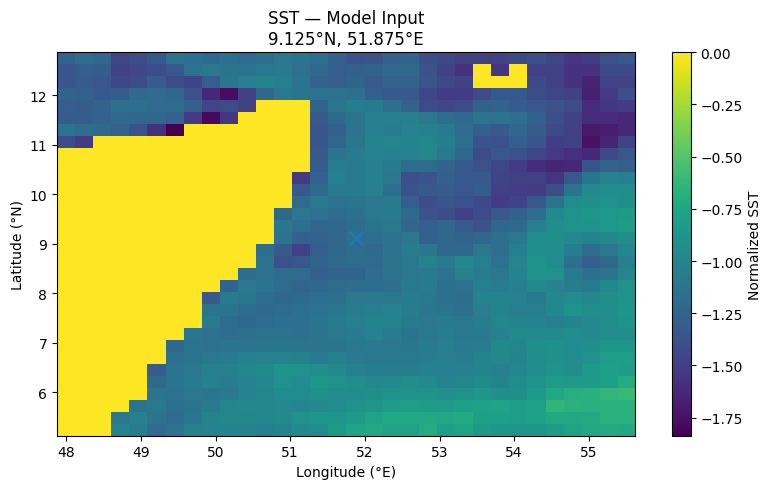

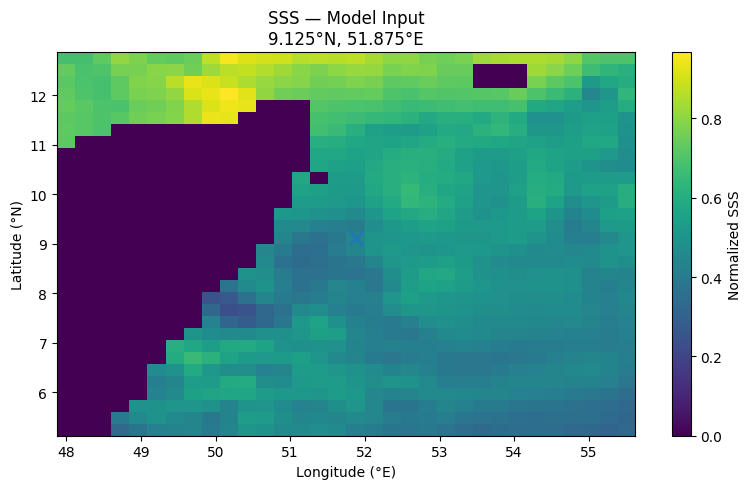

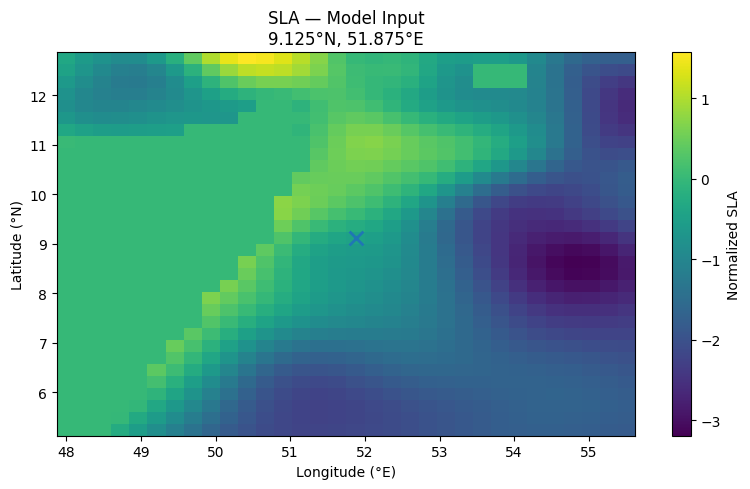

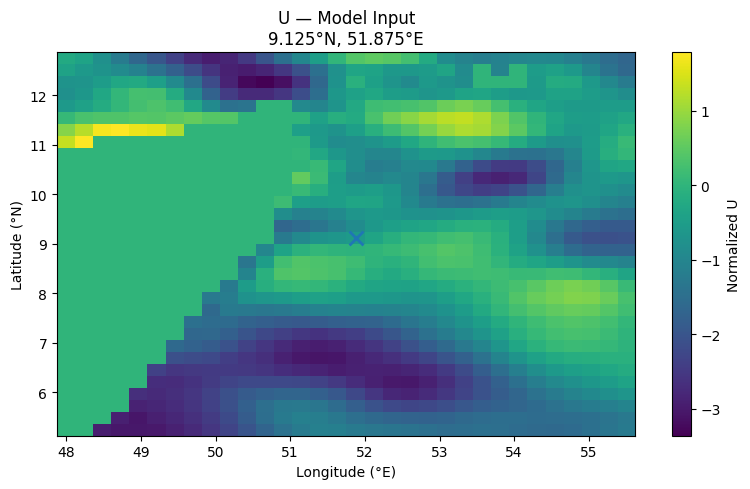

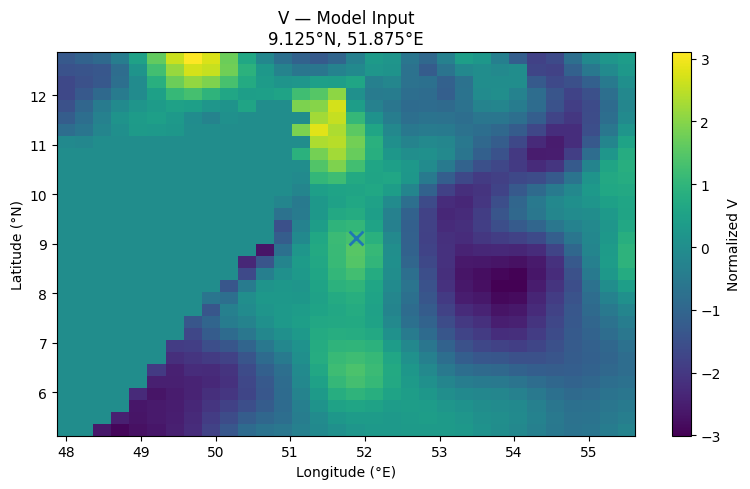

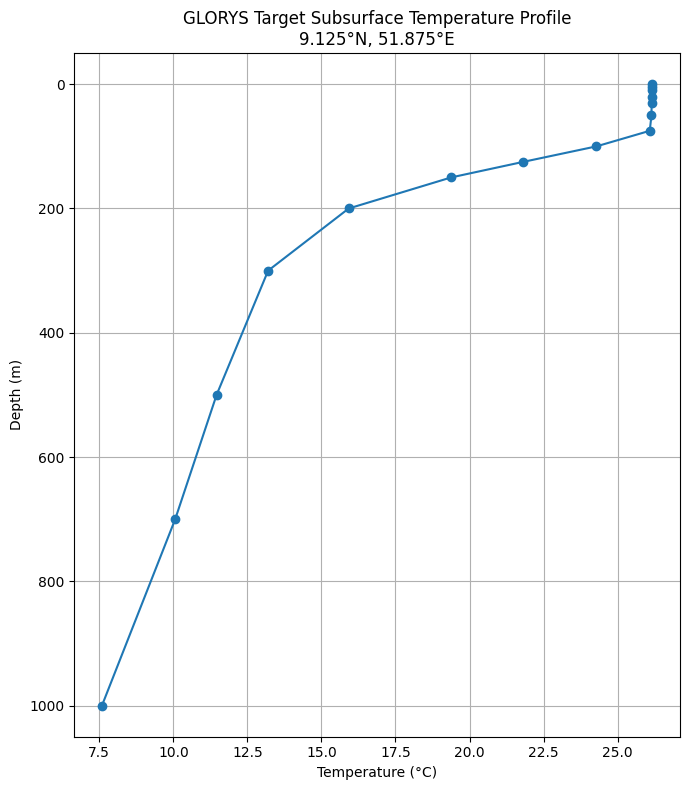


----------------------------------------------------------------------
TARGET PROFILE
----------------------------------------------------------------------
Depth =      0 m   Temperature =   26.177 °C
Depth =      5 m   Temperature =   26.173 °C
Depth =     10 m   Temperature =   26.164 °C
Depth =     20 m   Temperature =   26.154 °C
Depth =     30 m   Temperature =   26.148 °C
Depth =     50 m   Temperature =   26.144 °C
Depth =     75 m   Temperature =   26.085 °C
Depth =    100 m   Temperature =   24.287 °C
Depth =    125 m   Temperature =   21.811 °C
Depth =    150 m   Temperature =   19.380 °C
Depth =    200 m   Temperature =   15.920 °C
Depth =    300 m   Temperature =   13.201 °C
Depth =    500 m   Temperature =   11.460 °C
Depth =    700 m   Temperature =   10.063 °C
Depth =   1000 m   Temperature =    7.589 °C

SAMPLE VISUALIZATION COMPLETE


In [18]:
import matplotlib.pyplot as plt

print("=" * 70)
print("VISUALIZING ONE OCEANEMBED TRAINING SAMPLE")
print("=" * 70)

# ---------------------------------------------------------
# Select the first sample from the first batch
# ---------------------------------------------------------

sample_X = X_batch[0]
sample_y = y_batch[0]

# Coordinates of the first valid patch center
sample_lat_idx = int(valid_patch_centers[0, 0])
sample_lon_idx = int(valid_patch_centers[0, 1])

sample_center_lat = latitude[sample_lat_idx]
sample_center_lon = longitude[sample_lon_idx]

# ---------------------------------------------------------
# Patch geographic coordinates
# ---------------------------------------------------------

lat_start = sample_lat_idx - HALF_PATCH
lat_end = sample_lat_idx + HALF_PATCH

lon_start = sample_lon_idx - HALF_PATCH
lon_end = sample_lon_idx + HALF_PATCH

patch_latitude = latitude[lat_start:lat_end]
patch_longitude = longitude[lon_start:lon_end]

print("\nSample information:")
print(f"  Date              : {time[train_indices[0]]}")
print(f"  Center latitude   : {sample_center_lat:.3f}°N")
print(f"  Center longitude  : {sample_center_lon:.3f}°E")
print(f"  Patch size        : {sample_X.shape}")
print(f"  Target size       : {sample_y.shape}")

print("\nInput channels:")
for i, variable in enumerate(INPUT_VARIABLES):
    print(
        f"  {i}: {variable} "
        f"→ shape {sample_X[:, :, i].shape}"
    )

print("\nTarget depths:")
print(depths.astype(int).tolist())

# ---------------------------------------------------------
# Plot each input variable separately
# ---------------------------------------------------------

for channel, variable in enumerate(INPUT_VARIABLES):

    plt.figure(figsize=(8, 5))

    plt.imshow(
        sample_X[:, :, channel],
        extent=[
            patch_longitude[0],
            patch_longitude[-1],
            patch_latitude[0],
            patch_latitude[-1]
        ],
        origin="lower",
        aspect="auto"
    )

    plt.colorbar(
        label=f"Normalized {variable}"
    )

    plt.scatter(
        sample_center_lon,
        sample_center_lat,
        marker="x",
        s=100,
        linewidths=2
    )

    plt.xlabel("Longitude (°E)")
    plt.ylabel("Latitude (°N)")
    plt.title(
        f"{variable} — Model Input\n"
        f"{sample_center_lat:.3f}°N, "
        f"{sample_center_lon:.3f}°E"
    )

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Plot target temperature profile
# ---------------------------------------------------------

plt.figure(figsize=(7, 8))

plt.plot(
    sample_y,
    depths,
    marker="o"
)

plt.gca().invert_yaxis()

plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")

plt.title(
    "GLORYS Target Subsurface Temperature Profile\n"
    f"{sample_center_lat:.3f}°N, "
    f"{sample_center_lon:.3f}°E"
)

plt.grid(True)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Print target values
# ---------------------------------------------------------

print("\n" + "-" * 70)
print("TARGET PROFILE")
print("-" * 70)

for depth, temperature in zip(depths, sample_y):
    print(
        f"Depth = {depth:6.0f} m"
        f"   Temperature = {temperature:8.3f} °C"
    )

print("\n" + "=" * 70)
print("SAMPLE VISUALIZATION COMPLETE")
print("=" * 70)


In [19]:
print("=" * 70)
print("BUILDING OCEANEMBED CNN MODEL")
print("=" * 70)

from tensorflow.keras import layers, models

# ---------------------------------------------------------
# Input
# ---------------------------------------------------------

input_layer = layers.Input(
    shape=(
        PATCH_SIZE,
        PATCH_SIZE,
        NUM_INPUT_CHANNELS
    ),
    name="surface_inputs"
)

# ---------------------------------------------------------
# CNN feature extraction
# ---------------------------------------------------------

x = layers.Conv2D(
    32,
    kernel_size=3,
    padding="same",
    activation="relu",
    name="conv1"
)(input_layer)

x = layers.BatchNormalization(
    name="bn1"
)(x)

x = layers.MaxPooling2D(
    pool_size=2,
    name="pool1"
)(x)


x = layers.Conv2D(
    64,
    kernel_size=3,
    padding="same",
    activation="relu",
    name="conv2"
)(x)

x = layers.BatchNormalization(
    name="bn2"
)(x)

x = layers.MaxPooling2D(
    pool_size=2,
    name="pool2"
)(x)


x = layers.Conv2D(
    128,
    kernel_size=3,
    padding="same",
    activation="relu",
    name="conv3"
)(x)

x = layers.BatchNormalization(
    name="bn3"
)(x)

# ---------------------------------------------------------
# Convert spatial features into a global representation
# ---------------------------------------------------------

x = layers.GlobalAveragePooling2D(
    name="global_average_pool"
)(x)

# ---------------------------------------------------------
# Fully connected layers
# ---------------------------------------------------------

x = layers.Dense(
    128,
    activation="relu",
    name="dense1"
)(x)

x = layers.Dropout(
    0.2,
    name="dropout"
)(x)

# ---------------------------------------------------------
# Output: 15 temperature depths
# ---------------------------------------------------------

output_layer = layers.Dense(
    NUM_TARGET_DEPTHS,
    activation="linear",
    name="temperature_profile"
)(x)

# ---------------------------------------------------------
# Create model
# ---------------------------------------------------------

oceanembed_model = models.Model(
    inputs=input_layer,
    outputs=output_layer,
    name="OceanEmbed_CNN"
)

# ---------------------------------------------------------
# Compile
# ---------------------------------------------------------

oceanembed_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mse",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        )
    ]
)

# ---------------------------------------------------------
# Display model
# ---------------------------------------------------------

print("\n✅ Model created successfully.\n")

oceanembed_model.summary()

print("\n" + "=" * 70)
print("MODEL ARCHITECTURE READY")
print("=" * 70)

BUILDING OCEANEMBED CNN MODEL

✅ Model created successfully.



Model: "OceanEmbed_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ surface_inputs (InputLayer)     │ (None, 32, 32, 5)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pool             │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temperature_profile (Dense)     │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,167 (442.06 KB)

 Trainable params: 112,719 (440.31 KB)

 Non-trainable params: 448 (1.75 KB)


MODEL ARCHITECTURE READY


In [20]:
print("=" * 70)
print("TESTING OCEANEMBED MODEL FORWARD PASS")
print("=" * 70)

# ---------------------------------------------------------
# Get one batch from the training generator
# ---------------------------------------------------------

X_batch, y_batch = test_generator[0]

print("\nInput batch:")
print(f"  Shape : {X_batch.shape}")
print(f"  Dtype : {X_batch.dtype}")

print("\nTarget batch:")
print(f"  Shape : {y_batch.shape}")
print(f"  Dtype : {y_batch.dtype}")

# ---------------------------------------------------------
# Run model prediction
# ---------------------------------------------------------

predictions = oceanembed_model.predict(
    X_batch,
    verbose=0
)

print("\nModel output:")
print(f"  Shape : {predictions.shape}")
print(f"  Expected : (4, 15)")
print(f"  Dtype : {predictions.dtype}")

# ---------------------------------------------------------
# Check output values
# ---------------------------------------------------------

print("\nPrediction statistics:")
print(f"  Minimum : {predictions.min():.4f}")
print(f"  Maximum : {predictions.max():.4f}")
print(f"  Mean    : {predictions.mean():.4f}")
print(f"  Std     : {predictions.std():.4f}")

print("\nNaN check:")
print(f"  Prediction NaNs : {np.isnan(predictions).sum()}")
print(f"  Prediction finite : {np.isfinite(predictions).all()}")

# ---------------------------------------------------------
# Compare one predicted profile with target
# ---------------------------------------------------------

print("\n" + "-" * 70)
print("FIRST SAMPLE: PREDICTED vs TARGET")
print("-" * 70)

print(
    f"{'Depth (m)':>12} "
    f"{'Target (°C)':>15} "
    f"{'Prediction (°C)':>18}"
)

for depth, target, prediction in zip(
    depths,
    y_batch[0],
    predictions[0]
):

    print(
        f"{depth:12.0f} "
        f"{target:15.3f} "
        f"{prediction:18.3f}"
    )

# ---------------------------------------------------------
# Calculate initial untrained error
# ---------------------------------------------------------

initial_mae = np.mean(
    np.abs(predictions - y_batch)
)

initial_rmse = np.sqrt(
    np.mean(
        (predictions - y_batch) ** 2
    )
)

print("\n" + "-" * 70)
print("INITIAL UNTRAINED MODEL ERROR")
print("-" * 70)

print(f"  MAE  : {initial_mae:.4f} °C")
print(f"  RMSE : {initial_rmse:.4f} °C")

# ---------------------------------------------------------
# Final checks
# ---------------------------------------------------------

shape_ok = predictions.shape == (
    4,
    NUM_TARGET_DEPTHS
)

nan_ok = np.isfinite(predictions).all()

print("\n" + "=" * 70)

if shape_ok and nan_ok:
    print("✅ MODEL FORWARD PASS PASSED")
else:
    print("❌ MODEL FORWARD PASS FAILED")

print("=" * 70)

TESTING OCEANEMBED MODEL FORWARD PASS

Input batch:
  Shape : (4, 32, 32, 5)
  Dtype : float32

Target batch:
  Shape : (4, 15)
  Dtype : float32

Model output:
  Shape : (4, 15)
  Expected : (4, 15)
  Dtype : float32

Prediction statistics:
  Minimum : -0.2989
  Maximum : 0.1957
  Mean    : -0.0017
  Std     : 0.1326

NaN check:
  Prediction NaNs : 0
  Prediction finite : True

----------------------------------------------------------------------
FIRST SAMPLE: PREDICTED vs TARGET
----------------------------------------------------------------------
   Depth (m)     Target (°C)    Prediction (°C)
           0          26.177              0.125
           5          26.173              0.189
          10          26.164              0.116
          20          26.154              0.165
          30          26.148             -0.054
          50          26.144             -0.144
          75          26.085             -0.286
         100          24.287              0.008
         1

In [21]:
# ============================================================
# CELL 20 — CREATE TRAINING DATA GENERATOR
# ============================================================

print("=" * 70)
print("CREATING TRAINING DATA GENERATOR")
print("=" * 70)

# Training dates
train_day_indices = np.arange(0, len(train_time_indices))

# Make sure these variables exist
print("\nTraining days:", len(train_day_indices))
print("Valid patch centers:", len(valid_patch_centers))

# Create training generator
train_generator = OceanEmbedDataGenerator(
    day_indices=train_time_indices,
    patch_centers=valid_patch_centers,
    batch_size=32,
    shuffle=True
)

print("\n" + "-" * 70)
print("TRAINING GENERATOR CREATED")
print("-" * 70)

print("Training samples :", train_generator.total_samples)
print("Batch size       :", train_generator.batch_size)
print("Batches per epoch:", len(train_generator))

print("\n" + "=" * 70)
print("✅ CELL 20 COMPLETE")
print("=" * 70)

CREATING TRAINING DATA GENERATOR


NameError: name 'train_time_indices' is not defined

In [22]:
# ============================================================
# CELL 20 — RECREATE CHRONOLOGICAL DATA SPLIT
# ============================================================

print("=" * 70)
print("RECREATING CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT")
print("=" * 70)

# Get time coordinate directly from the processed dataset
dataset_time = processed_data["time"].values

# Total number of days
num_days = len(dataset_time)

print("\nTotal days:", num_days)
print("Start date:", pd.Timestamp(dataset_time[0]))
print("End date  :", pd.Timestamp(dataset_time[-1]))

# ------------------------------------------------------------
# Chronological split
# ------------------------------------------------------------
train_end = int(num_days * 0.70)
val_end = int(num_days * 0.85)

train_time_indices = np.arange(0, train_end)
val_time_indices = np.arange(train_end, val_end)
test_time_indices = np.arange(val_end, num_days)

# ------------------------------------------------------------
# Print split information
# ------------------------------------------------------------
print("\n" + "-" * 70)
print("CHRONOLOGICAL SPLIT")
print("-" * 70)

print(f"Train      : {len(train_time_indices)} days")
print(
    f"             {pd.Timestamp(dataset_time[train_time_indices[0]]).date()} "
    f"→ {pd.Timestamp(dataset_time[train_time_indices[-1]]).date()}"
)

print(f"Validation : {len(val_time_indices)} days")
print(
    f"             {pd.Timestamp(dataset_time[val_time_indices[0]]).date()} "
    f"→ {pd.Timestamp(dataset_time[val_time_indices[-1]]).date()}"
)

print(f"Test       : {len(test_time_indices)} days")
print(
    f"             {pd.Timestamp(dataset_time[test_time_indices[0]]).date()} "
    f"→ {pd.Timestamp(dataset_time[test_time_indices[-1]]).date()}"
)

# ------------------------------------------------------------
# Verify no overlap
# ------------------------------------------------------------
print("\n" + "-" * 70)
print("SPLIT VERIFICATION")
print("-" * 70)

train_val_overlap = np.intersect1d(
    train_time_indices,
    val_time_indices
)

train_test_overlap = np.intersect1d(
    train_time_indices,
    test_time_indices
)

val_test_overlap = np.intersect1d(
    val_time_indices,
    test_time_indices
)

print("Train ∩ Validation :", len(train_val_overlap))
print("Train ∩ Test       :", len(train_test_overlap))
print("Validation ∩ Test  :", len(val_test_overlap))

assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

assert (
    len(train_time_indices)
    + len(val_time_indices)
    + len(test_time_indices)
    == num_days
)

print("\n✅ No overlap between splits")
print("✅ All days accounted for")

print("\n" + "=" * 70)
print("✅ CELL 20 COMPLETE")
print("=" * 70)

RECREATING CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT

Total days: 455
Start date: 2025-01-01 00:00:00
End date  : 2026-03-31 00:00:00

----------------------------------------------------------------------
CHRONOLOGICAL SPLIT
----------------------------------------------------------------------
Train      : 318 days
             2025-01-01 → 2025-11-14
Validation : 68 days
             2025-11-15 → 2026-01-21
Test       : 69 days
             2026-01-22 → 2026-03-31

----------------------------------------------------------------------
SPLIT VERIFICATION
----------------------------------------------------------------------
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

✅ No overlap between splits
✅ All days accounted for

✅ CELL 20 COMPLETE


In [23]:
# ============================================================
# CELL 21 — CREATE TRAINING DATA GENERATOR
# ============================================================

print("=" * 70)
print("CREATING TRAINING DATA GENERATOR")
print("=" * 70)

train_generator = OceanEmbedDataGenerator(
    day_indices=train_time_indices,
    patch_centers=valid_patch_centers,
    batch_size=32,
    shuffle=True
)

print("\n" + "-" * 70)
print("TRAINING GENERATOR CREATED")
print("-" * 70)

print("Training days       :", len(train_time_indices))
print("Valid patch centers :", len(valid_patch_centers))
print("Training samples    :", train_generator.total_samples)
print("Batch size          :", train_generator.batch_size)
print("Batches per epoch   :", len(train_generator))

print("\n" + "=" * 70)
print("✅ CELL 21 COMPLETE")
print("=" * 70)

CREATING TRAINING DATA GENERATOR

----------------------------------------------------------------------
TRAINING GENERATOR CREATED
----------------------------------------------------------------------
Training days       : 318
Valid patch centers : 4996
Training samples    : 1588728
Batch size          : 32
Batches per epoch   : 49648

✅ CELL 21 COMPLETE


In [24]:
# ============================================================
# CELL 22 — GPU & DATA LOADER SPEED TEST
# ============================================================

import time as time_module

print("=" * 70)
print("GPU & DATA LOADER SPEED TEST")
print("=" * 70)

# ------------------------------------------------------------
# 1. GPU CHECK
# ------------------------------------------------------------
print("\nGPU INFORMATION")
print("-" * 70)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"✅ GPU detected: {len(gpus)}")
    for gpu in gpus:
        print("   ", gpu)
else:
    print("❌ No GPU detected")

print("\nTensorFlow version:", tf.__version__)

# ------------------------------------------------------------
# 2. GENERATOR INFORMATION
# ------------------------------------------------------------
print("\nDATA GENERATOR")
print("-" * 70)

print("Training samples :", train_generator.total_samples)
print("Batch size       :", train_generator.batch_size)
print("Batches/epoch    :", len(train_generator))

# ------------------------------------------------------------
# 3. FIRST BATCH
# ------------------------------------------------------------
print("\nTESTING FIRST BATCH")
print("-" * 70)

start = time_module.time()

X_speed, y_speed = train_generator[0]

first_batch_time = time_module.time() - start

print(f"First batch time : {first_batch_time:.3f} seconds")
print("X shape          :", X_speed.shape)
print("y shape          :", y_speed.shape)

# ------------------------------------------------------------
# 4. TEST 5 BATCHES
# ------------------------------------------------------------
print("\nTESTING 5 BATCHES")
print("-" * 70)

batch_times = []

for i in range(5):
    start = time_module.time()

    X_tmp, y_tmp = train_generator[i]

    elapsed = time_module.time() - start
    batch_times.append(elapsed)

    print(f"Batch {i + 1}: {elapsed:.3f} seconds")

avg_batch_time = np.mean(batch_times)

# ------------------------------------------------------------
# 5. EPOCH TIME ESTIMATE
# ------------------------------------------------------------
batches_per_epoch = len(train_generator)

estimated_seconds = avg_batch_time * batches_per_epoch
estimated_minutes = estimated_seconds / 60
estimated_hours = estimated_minutes / 60

print("\n" + "-" * 70)
print("TRAINING TIME ESTIMATE")
print("-" * 70)

print(f"Average batch time : {avg_batch_time:.3f} sec")
print(f"Batches/epoch     : {batches_per_epoch:,}")
print(f"Estimated epoch   : {estimated_minutes:,.1f} minutes")
print(f"Estimated epoch   : {estimated_hours:,.2f} hours")

# ------------------------------------------------------------
# 6. DATA VALIDATION
# ------------------------------------------------------------
print("\nDATA VALIDATION")
print("-" * 70)

print("X dtype       :", X_speed.dtype)
print("y dtype       :", y_speed.dtype)
print("X NaNs        :", np.isnan(X_speed).sum())
print("y NaNs        :", np.isnan(y_speed).sum())
print("X finite      :", np.isfinite(X_speed).all())
print("y finite      :", np.isfinite(y_speed).all())

print("\n" + "=" * 70)
print("✅ CELL 22 COMPLETE")
print("=" * 70)

GPU & DATA LOADER SPEED TEST

GPU INFORMATION
----------------------------------------------------------------------
✅ GPU detected: 1
    PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

TensorFlow version: 2.20.0

DATA GENERATOR
----------------------------------------------------------------------
Training samples : 1588728
Batch size       : 32
Batches/epoch    : 49648

TESTING FIRST BATCH
----------------------------------------------------------------------
First batch time : 1.107 seconds
X shape          : (32, 32, 32, 5)
y shape          : (32, 15)

TESTING 5 BATCHES
----------------------------------------------------------------------
Batch 1: 0.994 seconds
Batch 2: 1.018 seconds
Batch 3: 0.972 seconds
Batch 4: 0.984 seconds
Batch 5: 0.979 seconds

----------------------------------------------------------------------
TRAINING TIME ESTIMATE
----------------------------------------------------------------------
Average batch time : 0.989 sec
Batches/epoch    

In [25]:
# ============================================================
# CELL 23 — LOAD DATA INTO RAM FOR FAST TRAINING
# ============================================================

print("=" * 70)
print("LOADING PROCESSED DATA INTO RAM")
print("=" * 70)

# Load surface input variables
print("\nLoading surface variables...")

SST_array = processed_data["SST"].values.astype(np.float32)
SSS_array = processed_data["SSS"].values.astype(np.float32)
SLA_array = processed_data["SLA"].values.astype(np.float32)
U_array   = processed_data["U"].values.astype(np.float32)
V_array   = processed_data["V"].values.astype(np.float32)

print("SST:", SST_array.shape)
print("SSS:", SSS_array.shape)
print("SLA:", SLA_array.shape)
print("U  :", U_array.shape)
print("V  :", V_array.shape)

# Load GLORYS target
print("\nLoading GLORYS thetao target...")

thetao_array = processed_data["thetao"].values.astype(np.float32)

print("thetao:", thetao_array.shape)

# ------------------------------------------------------------
# Memory usage
# ------------------------------------------------------------

total_memory_gb = (
    SST_array.nbytes +
    SSS_array.nbytes +
    SLA_array.nbytes +
    U_array.nbytes +
    V_array.nbytes +
    thetao_array.nbytes
) / (1024 ** 3)

print("\n" + "-" * 70)
print("MEMORY USAGE")
print("-" * 70)

print(f"Total NumPy array memory: {total_memory_gb:.2f} GB")

# ------------------------------------------------------------
# Data validation
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("DATA VALIDATION")
print("-" * 70)

print("SST dtype:", SST_array.dtype)
print("SSS dtype:", SSS_array.dtype)
print("SLA dtype:", SLA_array.dtype)
print("U dtype  :", U_array.dtype)
print("V dtype  :", V_array.dtype)
print("thetao dtype:", thetao_array.dtype)

print("\nExpected shapes:")
print("Surface :", (455, 100, 240))
print("thetao  :", (455, 15, 100, 240))

assert SST_array.shape == (455, 100, 240)
assert SSS_array.shape == (455, 100, 240)
assert SLA_array.shape == (455, 100, 240)
assert U_array.shape   == (455, 100, 240)
assert V_array.shape   == (455, 100, 240)
assert thetao_array.shape == (455, 15, 100, 240)

print("\nShape checks: ✅ PASSED")

# Check finite values in ocean data
print("\nFinite-value checks:")

print("SST valid:", np.isfinite(SST_array).sum())
print("SSS valid:", np.isfinite(SSS_array).sum())
print("SLA valid:", np.isfinite(SLA_array).sum())
print("U valid  :", np.isfinite(U_array).sum())
print("V valid  :", np.isfinite(V_array).sum())
print("thetao valid:", np.isfinite(thetao_array).sum())

print("\n" + "=" * 70)
print("✅ CELL 23 COMPLETE")
print("=" * 70)

LOADING PROCESSED DATA INTO RAM

Loading surface variables...
SST: (455, 100, 240)
SSS: (455, 100, 240)
SLA: (455, 100, 240)
U  : (455, 100, 240)
V  : (455, 100, 240)

Loading GLORYS thetao target...
thetao: (455, 15, 100, 240)

----------------------------------------------------------------------
MEMORY USAGE
----------------------------------------------------------------------
Total NumPy array memory: 0.81 GB

----------------------------------------------------------------------
DATA VALIDATION
----------------------------------------------------------------------
SST dtype: float32
SSS dtype: float32
SLA dtype: float32
U dtype  : float32
V dtype  : float32
thetao dtype: float32

Expected shapes:
Surface : (455, 100, 240)
thetao  : (455, 15, 100, 240)

Shape checks: ✅ PASSED

Finite-value checks:
SST valid: 5397665
SSS valid: 5318040
SLA valid: 5408585
U valid  : 5402215
V valid  : 5402215
thetao valid: 68942965

✅ CELL 23 COMPLETE


In [26]:
# ============================================================
# CELL 24 — FAST RAM-BASED DATA GENERATOR
# ============================================================

from tensorflow.keras.utils import Sequence

class FastOceanEmbedDataGenerator(Sequence):

    def __init__(
        self,
        day_indices,
        patch_centers,
        batch_size=32,
        shuffle=True
    ):
        self.day_indices = np.asarray(day_indices)
        self.patch_centers = np.asarray(patch_centers)
        self.batch_size = batch_size
        self.shuffle = shuffle

        # Total samples
        self.total_samples = (
            len(self.day_indices) * len(self.patch_centers)
        )

        # Create sample indices
        self.indices = np.arange(self.total_samples)

        self.on_epoch_end()

    def __len__(self):
        return int(
            np.ceil(self.total_samples / self.batch_size)
        )

    def __getitem__(self, batch_index):

        # Select batch sample indices
        start = batch_index * self.batch_size
        end = min(
            start + self.batch_size,
            self.total_samples
        )

        batch_indices = self.indices[start:end]

        X_batch = np.empty(
            (
                len(batch_indices),
                PATCH_SIZE,
                PATCH_SIZE,
                NUM_INPUT_CHANNELS
            ),
            dtype=np.float32
        )

        y_batch = np.empty(
            (
                len(batch_indices),
                NUM_TARGET_DEPTHS
            ),
            dtype=np.float32
        )

        for j, flat_index in enumerate(batch_indices):

            # Convert flat index → day + spatial center
            day_position = (
                flat_index // len(self.patch_centers)
            )

            center_position = (
                flat_index % len(self.patch_centers)
            )

            day_idx = self.day_indices[day_position]

            lat_idx = int(
                self.patch_centers[center_position, 0]
            )

            lon_idx = int(
                self.patch_centers[center_position, 1]
            )

            # Patch boundaries
            lat_start = lat_idx - HALF_PATCH
            lat_end   = lat_idx + HALF_PATCH

            lon_start = lon_idx - HALF_PATCH
            lon_end   = lon_idx + HALF_PATCH

            # ------------------------------------------------
            # Extract 5 input channels directly from RAM
            # ------------------------------------------------

            patch = np.stack(
                [
                    SST_array[
                        day_idx,
                        lat_start:lat_end,
                        lon_start:lon_end
                    ],
                    SSS_array[
                        day_idx,
                        lat_start:lat_end,
                        lon_start:lon_end
                    ],
                    SLA_array[
                        day_idx,
                        lat_start:lat_end,
                        lon_start:lon_end
                    ],
                    U_array[
                        day_idx,
                        lat_start:lat_end,
                        lon_start:lon_end
                    ],
                    V_array[
                        day_idx,
                        lat_start:lat_end,
                        lon_start:lon_end
                    ]
                ],
                axis=-1
            )

            # ------------------------------------------------
            # Normalize input
            # ------------------------------------------------

            patch = (
                patch - input_means
            ) / input_stds

            # Replace land / missing values
            patch = np.nan_to_num(
                patch,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            X_batch[j] = patch

            # ------------------------------------------------
            # Extract target GLORYS profile
            # ------------------------------------------------

            y_batch[j] = thetao_array[
                day_idx,
                :,
                lat_idx,
                lon_idx
            ]

        return X_batch, y_batch

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indices)


print("=" * 70)
print("FAST RAM-BASED GENERATOR CREATED")
print("=" * 70)

# Create a small test generator
fast_test_generator = FastOceanEmbedDataGenerator(
    day_indices=train_time_indices,
    patch_centers=valid_patch_centers,
    batch_size=32,
    shuffle=False
)

print("\nTraining samples :", fast_test_generator.total_samples)
print("Batch size       :", fast_test_generator.batch_size)
print("Batches/epoch    :", len(fast_test_generator))

print("\n" + "=" * 70)
print("✅ CELL 24 COMPLETE")
print("=" * 70)

FAST RAM-BASED GENERATOR CREATED

Training samples : 1588728
Batch size       : 32
Batches/epoch    : 49648

✅ CELL 24 COMPLETE


In [27]:
# ============================================================
# CELL 25 — BENCHMARK FAST RAM-BASED GENERATOR
# ============================================================

import time as time_module

print("=" * 70)
print("BENCHMARKING FAST RAM-BASED GENERATOR")
print("=" * 70)

batch_times = []

# Warm-up batch
print("\nWarm-up batch...")
_ = fast_test_generator[0]

# Benchmark 10 batches
print("\nTesting 10 batches:")
print("-" * 70)

for i in range(10):
    start = time_module.time()

    X_tmp, y_tmp = fast_test_generator[i]

    elapsed = time_module.time() - start
    batch_times.append(elapsed)

    print(f"Batch {i + 1:2d}: {elapsed:.4f} sec")

# Average
avg_batch_time = np.mean(batch_times)

print("\n" + "-" * 70)
print("BENCHMARK RESULT")
print("-" * 70)

print(f"Average batch time : {avg_batch_time:.4f} sec")
print(f"Previous generator : ~0.994 sec/batch")

# Epoch estimate
batches_per_epoch = len(fast_test_generator)

estimated_seconds = avg_batch_time * batches_per_epoch
estimated_minutes = estimated_seconds / 60
estimated_hours = estimated_minutes / 3600

print("\nESTIMATED EPOCH TIME")
print("-" * 70)

print(f"Batches per epoch : {batches_per_epoch:,}")
print(f"Estimated epoch   : {estimated_minutes:.2f} minutes")
print(f"Estimated epoch   : {estimated_hours:.2f} hours")

# Speed improvement
old_time = 0.994

speedup = old_time / avg_batch_time

print("\nSPEED IMPROVEMENT")
print("-" * 70)

print(f"Speed improvement : {speedup:.2f}× faster")

# Validate output
print("\n" + "-" * 70)
print("OUTPUT VALIDATION")
print("-" * 70)

print("X shape :", X_tmp.shape)
print("y shape :", y_tmp.shape)
print("X dtype :", X_tmp.dtype)
print("y dtype :", y_tmp.dtype)
print("X NaNs  :", np.isnan(X_tmp).sum())
print("y NaNs  :", np.isnan(y_tmp).sum())
print("X finite:", np.isfinite(X_tmp).all())
print("y finite:", np.isfinite(y_tmp).all())

assert X_tmp.shape == (32, 32, 32, 5)
assert y_tmp.shape == (32, 15)
assert np.isfinite(X_tmp).all()
assert np.isfinite(y_tmp).all()

print("\n" + "=" * 70)
print("✅ CELL 25 COMPLETE")
print("=" * 70)


BENCHMARKING FAST RAM-BASED GENERATOR

Warm-up batch...


NameError: name 'input_means' is not defined

In [28]:
# ============================================================
# CELL 25 — RESTORE TRAINING NORMALIZATION STATISTICS
# ============================================================

print("=" * 70)
print("RESTORING TRAINING NORMALIZATION STATISTICS")
print("=" * 70)

# ------------------------------------------------------------
# Calculate statistics using TRAINING PERIOD only
# and the common ocean mask
# ------------------------------------------------------------

training_mask = common_ocean_mask

train_sst = SST_array[train_time_indices][:, training_mask]
train_sss = SSS_array[train_time_indices][:, training_mask]
train_sla = SLA_array[train_time_indices][:, training_mask]
train_u   = U_array[train_time_indices][:, training_mask]
train_v   = V_array[train_time_indices][:, training_mask]

input_means = np.array([
    np.nanmean(train_sst),
    np.nanmean(train_sss),
    np.nanmean(train_sla),
    np.nanmean(train_u),
    np.nanmean(train_v)
], dtype=np.float32)

input_stds = np.array([
    np.nanstd(train_sst),
    np.nanstd(train_sss),
    np.nanstd(train_sla),
    np.nanstd(train_u),
    np.nanstd(train_v)
], dtype=np.float32)

# ------------------------------------------------------------
# Display statistics
# ------------------------------------------------------------

print("\nTRAINING-ONLY NORMALIZATION STATISTICS")
print("-" * 70)

for name, mean, std in zip(
    ["SST", "SSS", "SLA", "U", "V"],
    input_means,
    input_stds
):
    print(f"{name:5s} → Mean: {mean:.6f} | Std: {std:.6f}")

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert np.all(np.isfinite(input_means))
assert np.all(np.isfinite(input_stds))
assert np.all(input_stds > 0)

print("\n" + "-" * 70)
print("VERIFICATION")
print("-" * 70)

print("Means finite :", np.isfinite(input_means).all())
print("Stds finite  :", np.isfinite(input_stds).all())
print("Stds > 0     :", (input_stds > 0).all())

print("\n" + "=" * 70)
print("✅ CELL 25 COMPLETE")
print("=" * 70)

RESTORING TRAINING NORMALIZATION STATISTICS

TRAINING-ONLY NORMALIZATION STATISTICS
----------------------------------------------------------------------
SST   → Mean: 28.518791 | Std: 1.856114
SSS   → Mean: 34.605782 | Std: 2.033042
SLA   → Mean: 0.148476 | Std: 0.104107
U     → Mean: 0.064505 | Std: 0.286265
V     → Mean: 0.005081 | Std: 0.236481

----------------------------------------------------------------------
VERIFICATION
----------------------------------------------------------------------
Means finite : True
Stds finite  : True
Stds > 0     : True

✅ CELL 25 COMPLETE


In [29]:
# ============================================================
# CELL 26 — BENCHMARK FAST RAM-BASED GENERATOR
# ============================================================

import time as time_module

print("=" * 70)
print("BENCHMARKING FAST RAM-BASED GENERATOR")
print("=" * 70)

batch_times = []

# Warm-up
print("\nWarm-up batch...")
_ = fast_test_generator[0]

# Benchmark 10 batches
print("\nTesting 10 batches:")
print("-" * 70)

for i in range(10):
    start = time_module.time()

    X_tmp, y_tmp = fast_test_generator[i]

    elapsed = time_module.time() - start
    batch_times.append(elapsed)

    print(f"Batch {i + 1:2d}: {elapsed:.4f} sec")

# Average
avg_batch_time = np.mean(batch_times)

print("\n" + "-" * 70)
print("BENCHMARK RESULT")
print("-" * 70)

print(f"Average batch time : {avg_batch_time:.4f} sec")
print(f"Previous generator : ~0.994 sec/batch")

# Epoch estimate
batches_per_epoch = len(fast_test_generator)

estimated_seconds = avg_batch_time * batches_per_epoch
estimated_minutes = estimated_seconds / 60
estimated_hours = estimated_minutes / 3600

print("\nESTIMATED EPOCH TIME")
print("-" * 70)

print(f"Batches per epoch : {batches_per_epoch:,}")
print(f"Estimated epoch   : {estimated_minutes:.2f} minutes")
print(f"Estimated epoch   : {estimated_hours:.2f} hours")

# Speed improvement
old_time = 0.994
speedup = old_time / avg_batch_time

print("\nSPEED IMPROVEMENT")
print("-" * 70)

print(f"Speed improvement : {speedup:.2f}× faster")

# Validate output
print("\n" + "-" * 70)
print("OUTPUT VALIDATION")
print("-" * 70)

print("X shape :", X_tmp.shape)
print("y shape :", y_tmp.shape)
print("X dtype :", X_tmp.dtype)
print("y dtype :", y_tmp.dtype)
print("X NaNs  :", np.isnan(X_tmp).sum())
print("y NaNs  :", np.isnan(y_tmp).sum())
print("X finite:", np.isfinite(X_tmp).all())
print("y finite:", np.isfinite(y_tmp).all())

assert X_tmp.shape == (32, 32, 32, 5)
assert y_tmp.shape == (32, 15)
assert np.isfinite(X_tmp).all()
assert np.isfinite(y_tmp).all()

print("\n" + "=" * 70)
print("✅ CELL 26 COMPLETE")
print("=" * 70)

BENCHMARKING FAST RAM-BASED GENERATOR

Warm-up batch...

Testing 10 batches:
----------------------------------------------------------------------
Batch  1: 0.0022 sec
Batch  2: 0.0018 sec
Batch  3: 0.0018 sec
Batch  4: 0.0019 sec
Batch  5: 0.0019 sec
Batch  6: 0.0019 sec
Batch  7: 0.0019 sec
Batch  8: 0.0018 sec
Batch  9: 0.0017 sec
Batch 10: 0.0019 sec

----------------------------------------------------------------------
BENCHMARK RESULT
----------------------------------------------------------------------
Average batch time : 0.0019 sec
Previous generator : ~0.994 sec/batch

ESTIMATED EPOCH TIME
----------------------------------------------------------------------
Batches per epoch : 49,648
Estimated epoch   : 1.56 minutes
Estimated epoch   : 0.00 hours

SPEED IMPROVEMENT
----------------------------------------------------------------------
Speed improvement : 527.76× faster

----------------------------------------------------------------------
OUTPUT VALIDATION
-------------

In [31]:
# ============================================================
# CELL 27 — CREATE VALIDATION & TEST GENERATORS
# ============================================================

print("=" * 70)
print("CREATING VALIDATION & TEST GENERATORS")
print("=" * 70)

# ------------------------------------------------------------
# Validation generator
# ------------------------------------------------------------

val_generator = FastOceanEmbedDataGenerator(
    day_indices=val_time_indices,
    patch_centers=valid_patch_centers,
    batch_size=32,
    shuffle=False
)

# ------------------------------------------------------------
# Test generator
# ------------------------------------------------------------

test_generator = FastOceanEmbedDataGenerator(
    day_indices=test_time_indices,
    patch_centers=valid_patch_centers,
    batch_size=32,
    shuffle=False
)

# ------------------------------------------------------------
# Display information
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("VALIDATION GENERATOR")
print("-" * 70)

print("Days           :", len(val_time_indices))
print("Samples        :", val_generator.total_samples)
print("Batch size     :", val_generator.batch_size)
print("Batches        :", len(val_generator))
print("Shuffle        :", val_generator.shuffle)

print("\n" + "-" * 70)
print("TEST GENERATOR")
print("-" * 70)

print("Days           :", len(test_time_indices))
print("Samples        :", test_generator.total_samples)
print("Batch size     :", test_generator.batch_size)
print("Batches        :", len(test_generator))
print("Shuffle        :", test_generator.shuffle)

# ------------------------------------------------------------
# Expected counts
# ------------------------------------------------------------

assert val_generator.total_samples == 68 * len(valid_patch_centers)
assert test_generator.total_samples == 69 * len(valid_patch_centers)

assert val_generator.shuffle is False
assert test_generator.shuffle is False

print("\n" + "-" * 70)
print("VERIFICATION")
print("-" * 70)

print("Validation sample count: ✅")
print("Test sample count      : ✅")
print("Validation shuffle=False: ✅")
print("Test shuffle=False      : ✅")

print("\n" + "=" * 70)
print("✅ CELL 27 COMPLETE")
print("=" * 70)

CREATING VALIDATION & TEST GENERATORS

----------------------------------------------------------------------
VALIDATION GENERATOR
----------------------------------------------------------------------
Days           : 68
Samples        : 339728
Batch size     : 32
Batches        : 10617
Shuffle        : False

----------------------------------------------------------------------
TEST GENERATOR
----------------------------------------------------------------------
Days           : 69
Samples        : 344724
Batch size     : 32
Batches        : 10773
Shuffle        : False

----------------------------------------------------------------------
VERIFICATION
----------------------------------------------------------------------
Validation sample count: ✅
Test sample count      : ✅
Validation shuffle=False: ✅
Test shuffle=False      : ✅

✅ CELL 27 COMPLETE


In [32]:
# ============================================================
# CELL 28 — VERIFY VALIDATION & TEST BATCHES
# ============================================================

print("=" * 70)
print("VERIFYING VALIDATION & TEST BATCHES")
print("=" * 70)

# ------------------------------------------------------------
# Validation batch
# ------------------------------------------------------------

print("\nVALIDATION BATCH")
print("-" * 70)

X_val_check, y_val_check = val_generator[0]

print("X shape :", X_val_check.shape)
print("y shape :", y_val_check.shape)
print("X dtype :", X_val_check.dtype)
print("y dtype :", y_val_check.dtype)
print("X NaNs  :", np.isnan(X_val_check).sum())
print("y NaNs  :", np.isnan(y_val_check).sum())
print("X finite:", np.isfinite(X_val_check).all())
print("y finite:", np.isfinite(y_val_check).all())

# ------------------------------------------------------------
# Test batch
# ------------------------------------------------------------

print("\nTEST BATCH")
print("-" * 70)

X_test_check, y_test_check = test_generator[0]

print("X shape :", X_test_check.shape)
print("y shape :", y_test_check.shape)
print("X dtype :", X_test_check.dtype)
print("y dtype :", y_test_check.dtype)
print("X NaNs  :", np.isnan(X_test_check).sum())
print("y NaNs  :", np.isnan(y_test_check).sum())
print("X finite:", np.isfinite(X_test_check).all())
print("y finite:", np.isfinite(y_test_check).all())

# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert X_val_check.shape == (32, 32, 32, 5)
assert y_val_check.shape == (32, 15)

assert X_test_check.shape == (32, 32, 32, 5)
assert y_test_check.shape == (32, 15)

assert np.isfinite(X_val_check).all()
assert np.isfinite(y_val_check).all()

assert np.isfinite(X_test_check).all()
assert np.isfinite(y_test_check).all()

print("\n" + "-" * 70)
print("VERIFICATION")
print("-" * 70)

print("Validation batch: ✅")
print("Test batch      : ✅")
print("Shapes          : ✅")
print("Finite values   : ✅")

print("\n" + "=" * 70)
print("✅ CELL 28 COMPLETE")
print("=" * 70)

VERIFYING VALIDATION & TEST BATCHES

VALIDATION BATCH
----------------------------------------------------------------------
X shape : (32, 32, 32, 5)
y shape : (32, 15)
X dtype : float32
y dtype : float32
X NaNs  : 0
y NaNs  : 0
X finite: True
y finite: True

TEST BATCH
----------------------------------------------------------------------
X shape : (32, 32, 32, 5)
y shape : (32, 15)
X dtype : float32
y dtype : float32
X NaNs  : 0
y NaNs  : 0
X finite: True
y finite: True

----------------------------------------------------------------------
VERIFICATION
----------------------------------------------------------------------
Validation batch: ✅
Test batch      : ✅
Shapes          : ✅
Finite values   : ✅

✅ CELL 28 COMPLETE


In [33]:
# ============================================================
# CELL 29 — TRAINING CALLBACKS
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger
)

print("=" * 70)
print("CONFIGURING TRAINING CALLBACKS")
print("=" * 70)

# Directory for training outputs
checkpoint_dir = Path("/content/oceanembed_training")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Save best model
# ------------------------------------------------------------

checkpoint_path = checkpoint_dir / "best_oceanembed_model.keras"

model_checkpoint = ModelCheckpoint(
    filepath=str(checkpoint_path),
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

# ------------------------------------------------------------
# 2. Stop if validation loss stops improving
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# 3. Reduce learning rate when validation plateaus
# ------------------------------------------------------------

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# ------------------------------------------------------------
# 4. Save training history to CSV
# ------------------------------------------------------------

csv_logger = CSVLogger(
    filename=str(checkpoint_dir / "training_history.csv"),
    append=False
)

callbacks = [
    model_checkpoint,
    early_stopping,
    reduce_lr,
    csv_logger
]

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("\nTraining output directory:")
print(checkpoint_dir)

print("\nBest model:")
print(checkpoint_path)

print("\nCallbacks:")
print("  ✓ ModelCheckpoint")
print("  ✓ EarlyStopping")
print("  ✓ ReduceLROnPlateau")
print("  ✓ CSVLogger")

print("\nConfiguration:")
print("  Monitor       : val_loss")
print("  Early stopping: patience = 5")
print("  LR reduction  : factor = 0.5")
print("  LR patience   : 2")
print("  Minimum LR    : 1e-6")

print("\n" + "=" * 70)
print("✅ CELL 29 COMPLETE")
print("=" * 70)

CONFIGURING TRAINING CALLBACKS

Training output directory:
/content/oceanembed_training

Best model:
/content/oceanembed_training/best_oceanembed_model.keras

Callbacks:
  ✓ ModelCheckpoint
  ✓ EarlyStopping
  ✓ ReduceLROnPlateau
  ✓ CSVLogger

Configuration:
  Monitor       : val_loss
  Early stopping: patience = 5
  LR reduction  : factor = 0.5
  LR patience   : 2
  Minimum LR    : 1e-6

✅ CELL 29 COMPLETE


In [34]:
# ============================================================
# CELL 30 — FINAL TRAINING CONFIGURATION CHECK
# ============================================================

print("=" * 70)
print("FINAL TRAINING CONFIGURATION CHECK")
print("=" * 70)

# ------------------------------------------------------------
# GPU
# ------------------------------------------------------------

print("\nGPU")
print("-" * 70)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("✅ GPU available")
    for gpu in gpus:
        print("   ", gpu)
else:
    print("❌ GPU not detected")

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

print("\nMODEL")
print("-" * 70)

print("Input shape  :", oceanembed_model.input_shape)
print("Output shape :", oceanembed_model.output_shape)
print("Parameters   :", oceanembed_model.count_params())

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

print("\nOPTIMIZER")
print("-" * 70)

print("Optimizer:", oceanembed_model.optimizer.__class__.__name__)
print("Learning rate:",
      float(tf.keras.backend.get_value(
          oceanembed_model.optimizer.learning_rate
      )))

# ------------------------------------------------------------
# Generators
# ------------------------------------------------------------

print("\nDATA")
print("-" * 70)

print("Training samples   :", train_generator.total_samples)
print("Validation samples :", val_generator.total_samples)
print("Test samples       :", test_generator.total_samples)

print("Training batches   :", len(train_generator))
print("Validation batches :", len(val_generator))
print("Test batches       :", len(test_generator))

# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------

print("\nCALLBACKS")
print("-" * 70)

for callback in callbacks:
    print("✓", callback.__class__.__name__)

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

print("\nOUTPUT")
print("-" * 70)

print("Training directory:")
print(checkpoint_dir)

print("Best model:")
print(checkpoint_path)

# ------------------------------------------------------------
# Final checks
# ------------------------------------------------------------

assert gpus, "GPU is not available"
assert oceanembed_model.input_shape == (None, 32, 32, 5)
assert oceanembed_model.output_shape == (None, 15)
assert train_generator.total_samples == 1588728
assert val_generator.total_samples == 339728
assert test_generator.total_samples == 344724

print("\n" + "=" * 70)
print("✅ ALL FINAL CHECKS PASSED")
print("=" * 70)

print("\nReady for training.")

FINAL TRAINING CONFIGURATION CHECK

GPU
----------------------------------------------------------------------
✅ GPU available
    PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

MODEL
----------------------------------------------------------------------
Input shape  : (None, 32, 32, 5)
Output shape : (None, 15)
Parameters   : 113167

OPTIMIZER
----------------------------------------------------------------------
Optimizer: Adam
Learning rate: 0.0010000000474974513

DATA
----------------------------------------------------------------------
Training samples   : 1588728
Validation samples : 339728
Test samples       : 344724
Training batches   : 49648
Validation batches : 10617
Test batches       : 10773

CALLBACKS
----------------------------------------------------------------------
✓ ModelCheckpoint
✓ EarlyStopping
✓ ReduceLROnPlateau
✓ CSVLogger

OUTPUT
----------------------------------------------------------------------
Training directory:
/content/oceanembed_

In [35]:
# ============================================================
# CELL 31 — TRAIN OCEANEMBED CNN
# ============================================================

print("=" * 70)
print("STARTING OCEANEMBED MODEL TRAINING")
print("=" * 70)

print("\nMaximum epochs : 2")
print("Training batches:", len(train_generator))
print("Validation batches:", len(val_generator))
print("Batch size:", train_generator.batch_size)

print("\nTraining started...\n")

training_start_time = time_module.time()

history = oceanembed_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2,
    callbacks=callbacks,
    verbose=1
)

training_time = time_module.time() - training_start_time

print("\n" + "=" * 70)
print("✅ TRAINING COMPLETE")
print("=" * 70)

print(f"\nTotal training time: {training_time / 60:.2f} minutes")

print("\nEpochs completed:", len(history.history["loss"]))

print("\nFinal training metrics:")
print(f"  Loss     : {history.history['loss'][-1]:.6f}")
print(f"  MAE      : {history.history['mae'][-1]:.6f}")
print(f"  Val Loss : {history.history['val_loss'][-1]:.6f}")
print(f"  Val MAE  : {history.history['val_mae'][-1]:.6f}")

print("\nBest model saved at:")
print(checkpoint_path)

print("\n" + "=" * 70)

STARTING OCEANEMBED MODEL TRAINING

Maximum epochs : 2
Training batches: 49648
Validation batches: 10617
Batch size: 32

Training started...



/usr/local/lib/python3.13/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
49648/49648 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 5.6900 - mae: 1.3667
Epoch 1: val_loss improved from None to 0.55711, saving model to /content/oceanembed_training/best_oceanembed_model.keras

Epoch 1: finished saving model to /content/oceanembed_training/best_oceanembed_model.keras
49648/49648 ━━━━━━━━━━━━━━━━━━━━ 4462s 90ms/step - loss: 2.1394 - mae: 1.0067 - val_loss: 0.5571 - val_mae: 0.5357 - learning_rate: 0.0010
Epoch 2/2
49648/49648 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.9667 - mae: 0.7490
Epoch 2: val_loss improved from 0.55711 to 0.54809, saving model to /content/oceanembed_training/best_oceanembed_model.keras

Epoch 2: finished saving model to /content/oceanembed_training/best_oceanembed_model.keras
49648/49648 ━━━━━━━━━━━━━━━━━━━━ 4386s 88ms/step - loss: 0.8536 - mae: 0.7020 - val_loss: 0.5481 - val_mae: 0.5248 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.

✅ TRAINING COMPLETE

Total training time: 147.47 minutes

Epo

In [36]:
# ============================================================
# CELL 32 — LOAD BEST MODEL & TEST EVALUATION
# ============================================================

import tensorflow as tf
import numpy as np

print("=" * 70)
print("LOADING BEST OCEANEMBED MODEL")
print("=" * 70)

best_model_path = "/content/oceanembed_training/best_oceanembed_model.keras"

best_model = tf.keras.models.load_model(best_model_path)

print("\nModel loaded successfully.")
print("Input shape :", best_model.input_shape)
print("Output shape:", best_model.output_shape)
print("Parameters  :", best_model.count_params())

print("\n" + "=" * 70)
print("EVALUATING ON HELD-OUT GLORYS TEST SET")
print("=" * 70)

test_results = best_model.evaluate(
    test_generator,
    verbose=1
)

print("\n" + "=" * 70)
print("TEST RESULTS")
print("=" * 70)

for metric_name, metric_value in zip(
    best_model.metrics_names,
    test_results
):
    print(f"{metric_name:10s}: {metric_value:.6f}")

print("\n✅ Test evaluation completed.")

LOADING BEST OCEANEMBED MODEL

Model loaded successfully.
Input shape : (None, 32, 32, 5)
Output shape: (None, 15)
Parameters  : 113167

EVALUATING ON HELD-OUT GLORYS TEST SET
10773/10773 ━━━━━━━━━━━━━━━━━━━━ 67s 6ms/step - loss: 0.5208 - mae: 0.5252

TEST RESULTS
loss      : 0.520788
compile_metrics: 0.525203

✅ Test evaluation completed.


In [37]:
# ============================================================
# CELL 33 — GENERATE PREDICTIONS FOR GLORYS TEST SET
# ============================================================

print("=" * 70)
print("GENERATING TEST PREDICTIONS")
print("=" * 70)

# Generate predictions
test_predictions = best_model.predict(
    test_generator,
    verbose=1
)

print("\n" + "=" * 70)
print("PREDICTIONS GENERATED")
print("=" * 70)

print("Predictions shape :", test_predictions.shape)

# Collect actual GLORYS target values
test_actual = []

for batch_idx in range(len(test_generator)):
    _, y_batch = test_generator[batch_idx]
    test_actual.append(y_batch)

test_actual = np.concatenate(test_actual, axis=0)

print("Actual shape      :", test_actual.shape)

# Safety check
assert test_predictions.shape == test_actual.shape
assert test_predictions.shape[1] == 15

print("\nNaNs in predictions:", np.isnan(test_predictions).sum())
print("NaNs in actual     :", np.isnan(test_actual).sum())

print("\nPrediction range:")
print("  Min:", np.min(test_predictions))
print("  Max:", np.max(test_predictions))

print("\nActual range:")
print("  Min:", np.min(test_actual))
print("  Max:", np.max(test_actual))

print("\n✅ Prediction generation completed successfully.")

GENERATING TEST PREDICTIONS
10773/10773 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step

PREDICTIONS GENERATED
Predictions shape : (344724, 15)
Actual shape      : (344724, 15)

NaNs in predictions: 0
NaNs in actual     : 0

Prediction range:
  Min: 6.468153
  Max: 30.603186

Actual range:
  Min: 5.937163
  Max: 31.040712

✅ Prediction generation completed successfully.


In [38]:
# ============================================================
# CELL 34 — DEPTH-WISE PERFORMANCE
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("DEPTH-WISE TEST PERFORMANCE")
print("=" * 80)

# Calculate errors
errors = test_predictions - test_actual

# Depth-wise metrics
mae_by_depth = np.mean(np.abs(errors), axis=0)
rmse_by_depth = np.sqrt(np.mean(errors**2, axis=0))
bias_by_depth = np.mean(errors, axis=0)

mean_actual_by_depth = np.mean(test_actual, axis=0)
mean_pred_by_depth = np.mean(test_predictions, axis=0)

# Create results table
depth_results = pd.DataFrame({
    "Depth_m": depths.astype(float),
    "Mean_Actual_C": mean_actual_by_depth,
    "Mean_Predicted_C": mean_pred_by_depth,
    "MAE_C": mae_by_depth,
    "RMSE_C": rmse_by_depth,
    "Bias_C": bias_by_depth
})

# Display rounded table
print("\n")
print(depth_results.round(4).to_string(index=False))

print("\n" + "=" * 80)

# Overall metrics calculated from all depth values
overall_mae = np.mean(np.abs(errors))
overall_rmse = np.sqrt(np.mean(errors**2))
overall_bias = np.mean(errors)

print("OVERALL TEST PERFORMANCE")
print("=" * 80)

print(f"Overall MAE  : {overall_mae:.4f} °C")
print(f"Overall RMSE : {overall_rmse:.4f} °C")
print(f"Overall Bias : {overall_bias:.4f} °C")

# Best and worst depths
best_mae_idx = np.argmin(mae_by_depth)
worst_mae_idx = np.argmax(mae_by_depth)

print("\nBest depth by MAE:")
print(
    f"  {depths[best_mae_idx]:.0f} m → "
    f"{mae_by_depth[best_mae_idx]:.4f} °C"
)

print("\nWorst depth by MAE:")
print(
    f"  {depths[worst_mae_idx]:.0f} m → "
    f"{mae_by_depth[worst_mae_idx]:.4f} °C"
)

print("\n✅ Depth-wise evaluation completed.")

DEPTH-WISE TEST PERFORMANCE


 Depth_m  Mean_Actual_C  Mean_Predicted_C  MAE_C  RMSE_C  Bias_C
     0.0      27.277700         27.424200 0.3544  0.4702  0.1504
     5.0      27.172701         27.367201 0.3668  0.4866  0.1967
    10.0      27.156099         27.368700 0.3740  0.4936  0.2154
    20.0      27.119600         27.329599 0.3982  0.5143  0.2129
    30.0      27.036501         27.273399 0.4587  0.5920  0.2412
    50.0      26.854401         26.946800 0.4973  0.6291  0.0901
    75.0      26.205799         26.013300 0.5839  0.7350 -0.1926
   100.0      24.371799         24.080700 0.8605  1.0742 -0.2913
   125.0      21.861900         21.717400 0.9733  1.2213 -0.1444
   150.0      19.492201         19.504400 0.9119  1.1398  0.0121
   200.0      16.291100         16.492001 0.6922  0.8727  0.2012
   300.0      13.452600         13.524300 0.4227  0.5666  0.0716
   500.0      11.461800         11.570000 0.3231  0.4281  0.1076
   700.0       9.947200         10.177800 0.3470  0.4374  0.

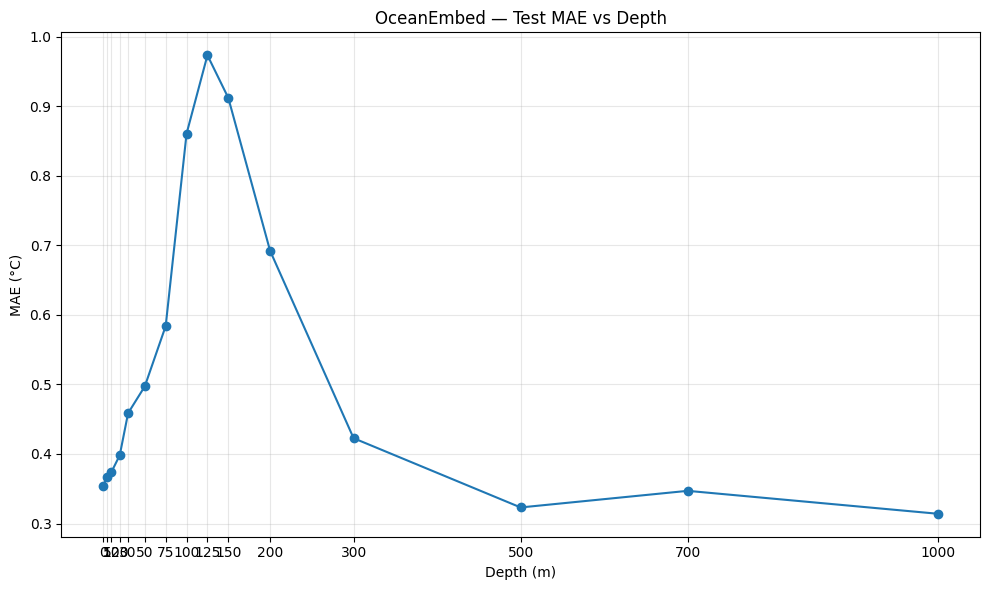

MAE range:
Minimum: 0.3140 °C
Maximum: 0.9733 °C


In [39]:
# ============================================================
# CELL 35 — MAE VS DEPTH
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    depth_results["Depth_m"],
    depth_results["MAE_C"],
    marker="o"
)

plt.xlabel("Depth (m)")
plt.ylabel("MAE (°C)")
plt.title("OceanEmbed — Test MAE vs Depth")
plt.grid(True, alpha=0.3)

plt.xticks(depth_results["Depth_m"])

plt.tight_layout()
plt.show()

print("MAE range:")
print(f"Minimum: {depth_results['MAE_C'].min():.4f} °C")
print(f"Maximum: {depth_results['MAE_C'].max():.4f} °C")

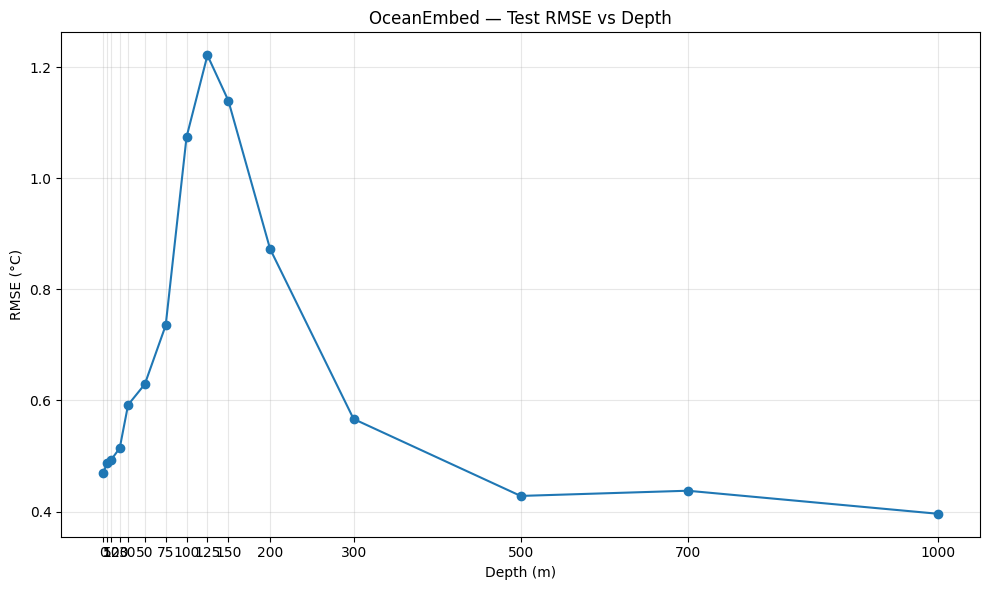

RMSE range:
Minimum: 0.3959 °C
Maximum: 1.2213 °C


In [40]:
# ============================================================
# CELL 36 — RMSE VS DEPTH
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    depth_results["Depth_m"],
    depth_results["RMSE_C"],
    marker="o"
)

plt.xlabel("Depth (m)")
plt.ylabel("RMSE (°C)")
plt.title("OceanEmbed — Test RMSE vs Depth")
plt.grid(True, alpha=0.3)

plt.xticks(depth_results["Depth_m"])

plt.tight_layout()
plt.show()

print("RMSE range:")
print(f"Minimum: {depth_results['RMSE_C'].min():.4f} °C")
print(f"Maximum: {depth_results['RMSE_C'].max():.4f} °C")


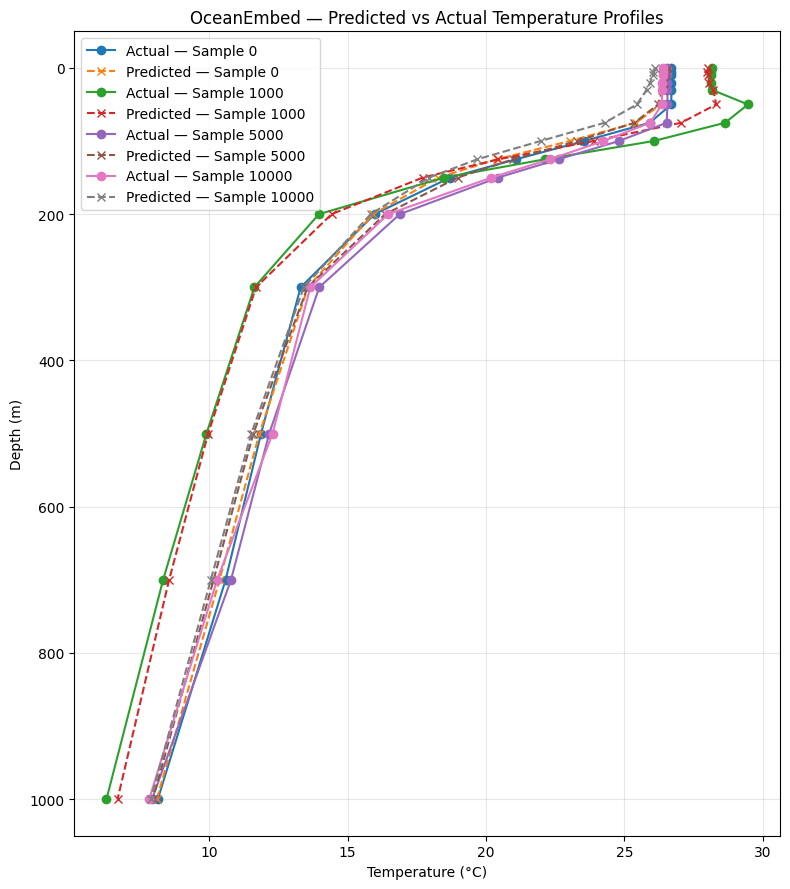

✅ Temperature profile comparison completed.


In [41]:
# ============================================================
# CELL 37 — PREDICTED VS ACTUAL TEMPERATURE PROFILES
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Select a few representative test samples
sample_indices = [0, 1000, 5000, 10000]

plt.figure(figsize=(8, 9))

for idx in sample_indices:
    plt.plot(
        test_actual[idx],
        depths,
        marker="o",
        linestyle="-",
        label=f"Actual — Sample {idx}"
    )

    plt.plot(
        test_predictions[idx],
        depths,
        marker="x",
        linestyle="--",
        label=f"Predicted — Sample {idx}"
    )

plt.gca().invert_yaxis()

plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title("OceanEmbed — Predicted vs Actual Temperature Profiles")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("✅ Temperature profile comparison completed.")

R² PERFORMANCE ANALYSIS

Depth-wise R²:
 Depth_m  MAE_C  RMSE_C  Bias_C     R2
     0.0 0.3544  0.4702  0.1504 0.8915
     5.0 0.3668  0.4866  0.1967 0.8794
    10.0 0.3740  0.4936  0.2154 0.8757
    20.0 0.3982  0.5143  0.2129 0.8660
    30.0 0.4587  0.5920  0.2412 0.8266
    50.0 0.4973  0.6291  0.0901 0.8176
    75.0 0.5839  0.7350 -0.1926 0.7667
   100.0 0.8605  1.0742 -0.2913 0.6015
   125.0 0.9733  1.2213 -0.1444 0.5302
   150.0 0.9119  1.1398  0.0121 0.5633
   200.0 0.6922  0.8727  0.2012 0.7069
   300.0 0.4227  0.5666  0.0716 0.8478
   500.0 0.3231  0.4281  0.1076 0.8768
   700.0 0.3470  0.4374  0.2312 0.8688
  1000.0 0.3140  0.3959  0.1409 0.8577

OVERALL R²
Overall R²: 0.9897


/tmp/ipykernel_1713/384785487.py:80: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


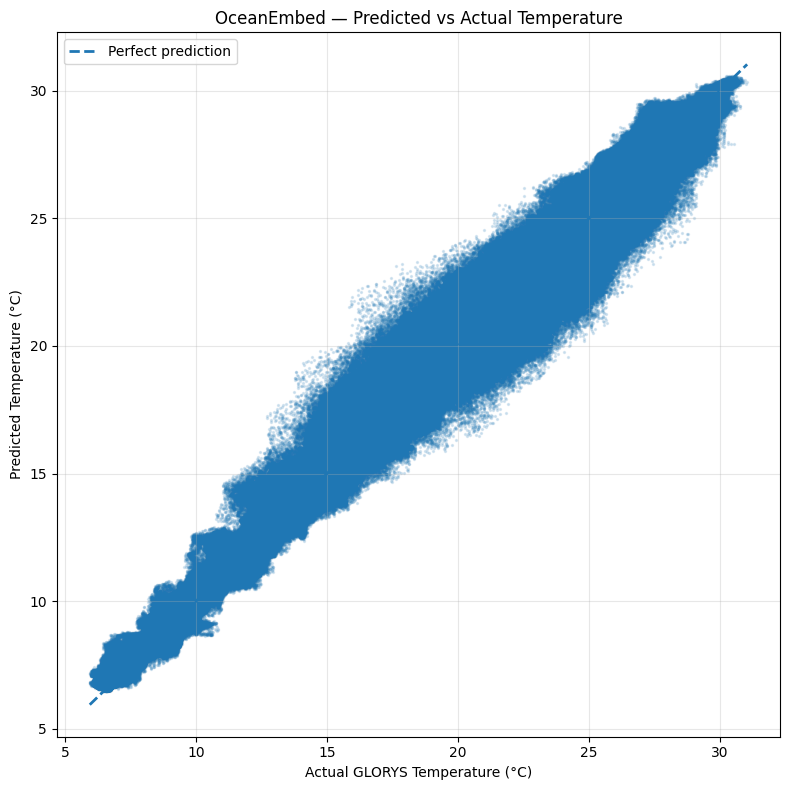


Best R² depth:
0 m → R² = 0.8915

Worst R² depth:
125 m → R² = 0.5302

✅ R² analysis completed.


In [42]:
# ============================================================
# CELL 38 — PREDICTED VS ACTUAL + R²
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

print("=" * 80)
print("R² PERFORMANCE ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Depth-wise R²
# ------------------------------------------------------------

r2_by_depth = np.array([
    r2_score(test_actual[:, i], test_predictions[:, i])
    for i in range(test_actual.shape[1])
])

depth_results["R2"] = r2_by_depth

print("\nDepth-wise R²:")
print(
    depth_results[
        ["Depth_m", "MAE_C", "RMSE_C", "Bias_C", "R2"]
    ].round(4).to_string(index=False)
)

# ------------------------------------------------------------
# Overall R²
# ------------------------------------------------------------

overall_r2 = r2_score(
    test_actual.reshape(-1),
    test_predictions.reshape(-1)
)

print("\n" + "=" * 80)
print("OVERALL R²")
print("=" * 80)

print(f"Overall R²: {overall_r2:.4f}")

# ------------------------------------------------------------
# Scatter plot
# ------------------------------------------------------------

actual_flat = test_actual.reshape(-1)
predicted_flat = test_predictions.reshape(-1)

plt.figure(figsize=(8, 8))

plt.scatter(
    actual_flat,
    predicted_flat,
    s=2,
    alpha=0.15
)

# Perfect prediction line
min_temp = min(actual_flat.min(), predicted_flat.min())
max_temp = max(actual_flat.max(), predicted_flat.max())

plt.plot(
    [min_temp, max_temp],
    [min_temp, max_temp],
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Actual GLORYS Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("OceanEmbed — Predicted vs Actual Temperature")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBest R² depth:")
best_r2_idx = np.argmax(r2_by_depth)
print(
    f"{depths[best_r2_idx]:.0f} m → "
    f"R² = {r2_by_depth[best_r2_idx]:.4f}"
)

print("\nWorst R² depth:")
worst_r2_idx = np.argmin(r2_by_depth)
print(
    f"{depths[worst_r2_idx]:.0f} m → "
    f"R² = {r2_by_depth[worst_r2_idx]:.4f}"
)

print("\n✅ R² analysis completed.")

In [43]:
# ============================================================
# CELL 39 — SAVE OCEANEMBED EVALUATION RESULTS
# ============================================================

from pathlib import Path
import json
import pandas as pd

output_dir = Path("/content/oceanembed_training")
output_dir.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("SAVING OCEANEMBED RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Save depth-wise results
# ------------------------------------------------------------

depth_results_path = output_dir / "depth_wise_test_results.csv"

depth_results.to_csv(
    depth_results_path,
    index=False
)

print("\n✓ Depth-wise results saved:")
print(depth_results_path)

# ------------------------------------------------------------
# 2. Save overall metrics
# ------------------------------------------------------------

overall_results = {
    "test_loss_mse": float(test_results[0]),
    "test_mae_c": float(overall_mae),
    "test_rmse_c": float(overall_rmse),
    "test_bias_c": float(overall_bias),
    "overall_r2": float(overall_r2),
    "epochs_completed": 2,
    "num_test_samples": int(len(test_actual)),
    "num_depths": int(test_actual.shape[1]),
    "depths_m": [float(d) for d in depths]
}

overall_results_path = output_dir / "overall_test_results.json"

with open(overall_results_path, "w") as f:
    json.dump(overall_results, f, indent=4)

print("\n✓ Overall results saved:")
print(overall_results_path)

# ------------------------------------------------------------
# 3. Save model explicitly
# ------------------------------------------------------------

final_model_path = output_dir / "oceanembed_2epoch_model.keras"

best_model.save(final_model_path)

print("\n✓ Model saved:")
print(final_model_path)

# ------------------------------------------------------------
# 4. Display final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print(f"Test MAE  : {overall_mae:.4f} °C")
print(f"Test RMSE : {overall_rmse:.4f} °C")
print(f"Test Bias : {overall_bias:.4f} °C")
print(f"Overall R²: {overall_r2:.4f}")

print("\nFiles created:")
print(f"  • {depth_results_path.name}")
print(f"  • {overall_results_path.name}")
print(f"  • {final_model_path.name}")

print("\n" + "=" * 70)
print("✅ RESULTS AND MODEL SAVED")
print("=" * 70)

SAVING OCEANEMBED RESULTS

✓ Depth-wise results saved:
/content/oceanembed_training/depth_wise_test_results.csv

✓ Overall results saved:
/content/oceanembed_training/overall_test_results.json

✓ Model saved:
/content/oceanembed_training/oceanembed_2epoch_model.keras

FINAL MODEL PERFORMANCE
Test MAE  : 0.5252 °C
Test RMSE : 0.7217 °C
Test Bias : 0.0829 °C
Overall R²: 0.9897

Files created:
  • depth_wise_test_results.csv
  • overall_test_results.json
  • oceanembed_2epoch_model.keras

✅ RESULTS AND MODEL SAVED


In [44]:
# ============================================================
# CELL 40 — PACKAGE MODEL + RESULTS FOR DOWNLOAD
# ============================================================

import shutil
from pathlib import Path
from google.colab import files

output_dir = Path("/content/oceanembed_training")
zip_path = Path("/content/oceanembed_training_results")

print("=" * 70)
print("PACKAGING OCEANEMBED MODEL AND RESULTS")
print("=" * 70)

# Create ZIP
shutil.make_archive(
    str(zip_path),
    "zip",
    root_dir="/content",
    base_dir="oceanembed_training"
)

final_zip = "/content/oceanembed_training_results.zip"

print("\n✓ ZIP created:")
print(final_zip)

print(f"✓ ZIP size: {Path(final_zip).stat().st_size / (1024**2):.2f} MB")

print("\nFiles inside training directory:")
for file in sorted(output_dir.iterdir()):
    if file.is_file():
        print(f"  • {file.name} ({file.stat().st_size / (1024**2):.2f} MB)")

print("\nStarting download...")

files.download(final_zip)

print("\n" + "=" * 70)
print("✅ DOWNLOAD STARTED")
print("=" * 70)

PACKAGING OCEANEMBED MODEL AND RESULTS

✓ ZIP created:
/content/oceanembed_training_results.zip
✓ ZIP size: 2.43 MB

Files inside training directory:
  • best_oceanembed_model.keras (1.36 MB)
  • depth_wise_test_results.csv (0.00 MB)
  • oceanembed_2epoch_model.keras (1.36 MB)
  • overall_test_results.json (0.00 MB)
  • training_history.csv (0.00 MB)

Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ DOWNLOAD STARTED


In [45]:
# ============================================================
# CELL 41 — SAVE TEST PREDICTIONS
# ============================================================

import numpy as np
from pathlib import Path

output_dir = Path("/content/oceanembed_training")

predictions_path = output_dir / "test_predictions.npz"

np.savez_compressed(
    predictions_path,
    predictions=test_predictions.astype(np.float32),
    actual=test_actual.astype(np.float32),
    depths=np.asarray(depths, dtype=np.float32)
)

print("=" * 70)
print("TEST PREDICTIONS SAVED")
print("=" * 70)

print(f"\nFile: {predictions_path}")
print(f"Size: {predictions_path.stat().st_size / (1024**2):.2f} MB")

print("\nSaved arrays:")
print("  Predictions:", test_predictions.shape)
print("  Actual     :", test_actual.shape)
print("  Depths     :", depths.shape)

print("\n✅ Test predictions safely saved.")

TEST PREDICTIONS SAVED

File: /content/oceanembed_training/test_predictions.npz
Size: 33.46 MB

Saved arrays:
  Predictions: (344724, 15)
  Actual     : (344724, 15)
  Depths     : (15,)

✅ Test predictions safely saved.


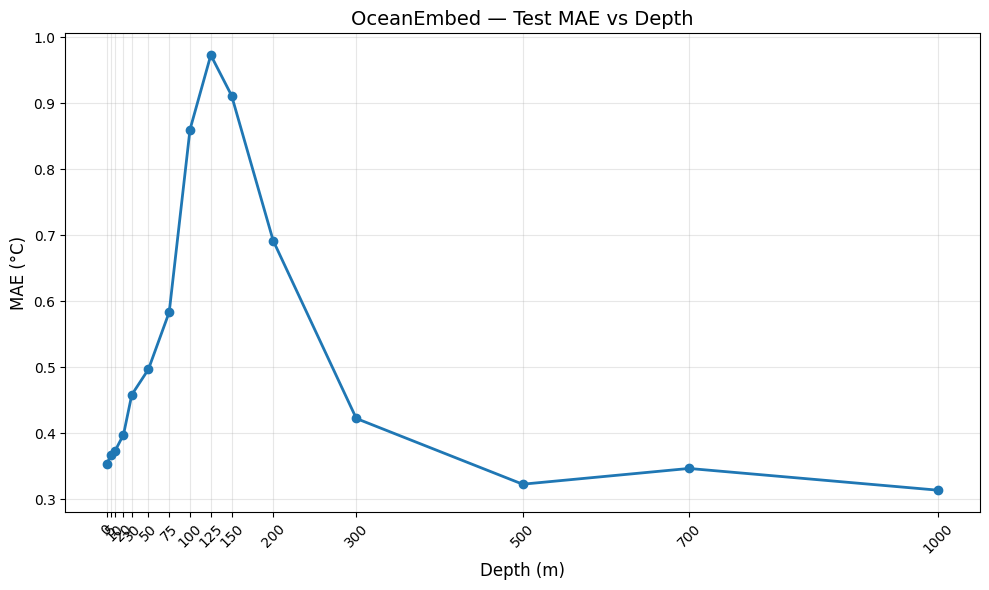

✓ Saved: /content/oceanembed_training/MAE_vs_Depth.png


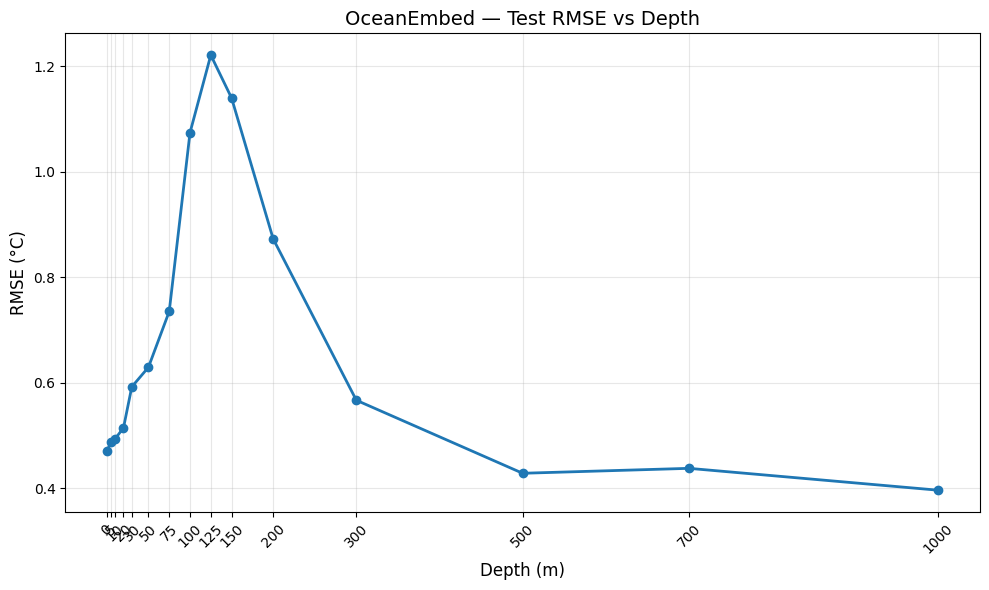

✓ Saved: /content/oceanembed_training/RMSE_vs_Depth.png


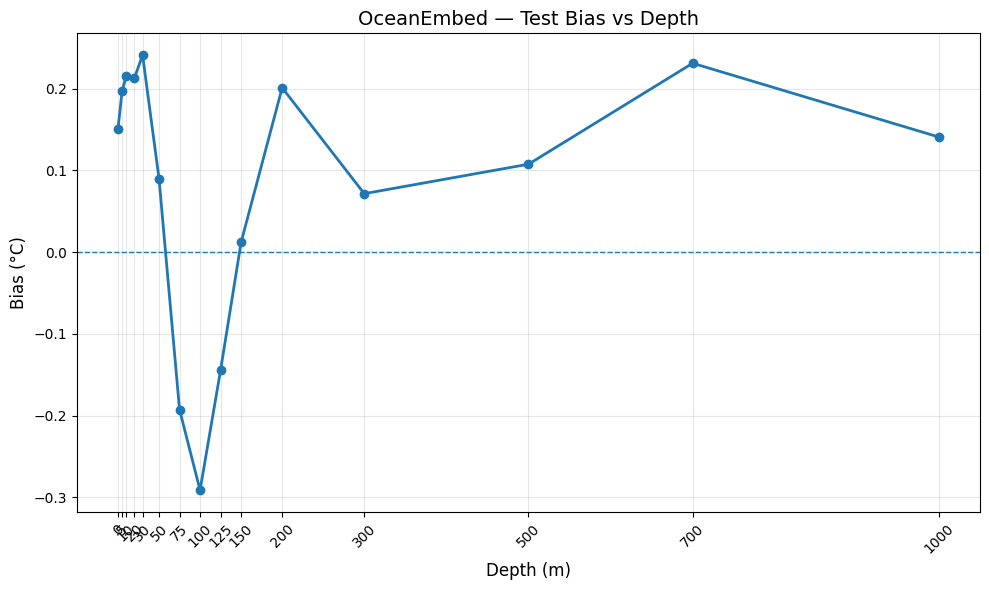

✓ Saved: /content/oceanembed_training/Bias_vs_Depth.png

✅ FINAL PERFORMANCE PLOTS CREATED


In [46]:
# ============================================================
# CELL 42 — FINAL PERFORMANCE PLOTS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

output_dir = Path("/content/oceanembed_training")

# ------------------------------------------------------------
# Plot 1 — MAE vs Depth
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    depth_results["Depth_m"],
    depth_results["MAE_C"],
    marker="o",
    linewidth=2,
    markersize=6
)

plt.xlabel("Depth (m)", fontsize=12)
plt.ylabel("MAE (°C)", fontsize=12)
plt.title("OceanEmbed — Test MAE vs Depth", fontsize=14)

plt.grid(True, alpha=0.3)
plt.xticks(depth_results["Depth_m"], rotation=45)

plt.tight_layout()

mae_plot_path = output_dir / "MAE_vs_Depth.png"
plt.savefig(mae_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"✓ Saved: {mae_plot_path}")


# ------------------------------------------------------------
# Plot 2 — RMSE vs Depth
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    depth_results["Depth_m"],
    depth_results["RMSE_C"],
    marker="o",
    linewidth=2,
    markersize=6
)

plt.xlabel("Depth (m)", fontsize=12)
plt.ylabel("RMSE (°C)", fontsize=12)
plt.title("OceanEmbed — Test RMSE vs Depth", fontsize=14)

plt.grid(True, alpha=0.3)
plt.xticks(depth_results["Depth_m"], rotation=45)

plt.tight_layout()

rmse_plot_path = output_dir / "RMSE_vs_Depth.png"
plt.savefig(rmse_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"✓ Saved: {rmse_plot_path}")


# ------------------------------------------------------------
# Plot 3 — Bias vs Depth
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    depth_results["Depth_m"],
    depth_results["Bias_C"],
    marker="o",
    linewidth=2,
    markersize=6
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Depth (m)", fontsize=12)
plt.ylabel("Bias (°C)", fontsize=12)
plt.title("OceanEmbed — Test Bias vs Depth", fontsize=14)

plt.grid(True, alpha=0.3)
plt.xticks(depth_results["Depth_m"], rotation=45)

plt.tight_layout()

bias_plot_path = output_dir / "Bias_vs_Depth.png"
plt.savefig(bias_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"✓ Saved: {bias_plot_path}")


print("\n" + "=" * 70)
print("✅ FINAL PERFORMANCE PLOTS CREATED")
print("=" * 70)

In [47]:
# ============================================================
# CELL 43 — FINAL OCEANEMBED RESULTS SUMMARY
# ============================================================

from pathlib import Path

output_dir = Path("/content/oceanembed_training")

# ------------------------------------------------------------
# Save complete depth-wise table
# ------------------------------------------------------------

final_table_path = output_dir / "OceanEmbed_final_depth_results.csv"

depth_results.to_csv(
    final_table_path,
    index=False
)

# ------------------------------------------------------------
# Create text summary
# ------------------------------------------------------------

summary_path = output_dir / "OceanEmbed_results_summary.txt"

best_depth_idx = depth_results["MAE_C"].idxmin()
worst_depth_idx = depth_results["MAE_C"].idxmax()

summary_text = f"""
OCEANEMBED — MODEL EVALUATION SUMMARY
======================================

Model:
CNN baseline for subsurface ocean temperature reconstruction

Input:
5 surface variables
- SST
- SSS
- SLA
- U surface current
- V surface current

Patch:
32 x 32 grid cells
0.25 degree spatial resolution
Approximately 8 x 8 degrees

Target:
GLORYS thetao temperature profile

Target depths:
0, 5, 10, 20, 30, 50, 75, 100, 125, 150,
200, 300, 500, 700, 1000 m

Training:
Epochs completed: 2

Held-out GLORYS test set:
Samples: {len(test_actual):,}

Overall Performance
-------------------
MAE  : {overall_mae:.4f} °C
RMSE : {overall_rmse:.4f} °C
Bias : {overall_bias:.4f} °C
R²   : {overall_r2:.4f}

Best Depth by MAE
-----------------
Depth: {depth_results.loc[best_depth_idx, "Depth_m"]:.0f} m
MAE  : {depth_results.loc[best_depth_idx, "MAE_C"]:.4f} °C

Worst Depth by MAE
------------------
Depth: {depth_results.loc[worst_depth_idx, "Depth_m"]:.0f} m
MAE  : {depth_results.loc[worst_depth_idx, "MAE_C"]:.4f} °C

Important:
This evaluation uses a held-out GLORYS test period.
It is NOT independent ARGO validation.

ARGO validation should be performed separately when
ARGO observations are available.
"""

with open(summary_path, "w") as f:
    f.write(summary_text.strip())

print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)

print(summary_text)

print("\nFiles saved:")
print(f"✓ {final_table_path}")
print(f"✓ {summary_path}")

print("\n" + "=" * 70)
print("✅ FINAL SUMMARY CREATED")
print("=" * 70)

FINAL RESULTS SUMMARY

OCEANEMBED — MODEL EVALUATION SUMMARY

Model:
CNN baseline for subsurface ocean temperature reconstruction

Input:
5 surface variables
- SST
- SSS
- SLA
- U surface current
- V surface current

Patch:
32 x 32 grid cells
0.25 degree spatial resolution
Approximately 8 x 8 degrees

Target:
GLORYS thetao temperature profile

Target depths:
0, 5, 10, 20, 30, 50, 75, 100, 125, 150,
200, 300, 500, 700, 1000 m

Training:
Epochs completed: 2

Held-out GLORYS test set:
Samples: 344,724

Overall Performance
-------------------
MAE  : 0.5252 °C
RMSE : 0.7217 °C
Bias : 0.0829 °C
R²   : 0.9897

Best Depth by MAE
-----------------
Depth: 1000 m
MAE  : 0.3140 °C

Worst Depth by MAE
------------------
Depth: 125 m
MAE  : 0.9733 °C

Important:
This evaluation uses a held-out GLORYS test period.
It is NOT independent ARGO validation.

ARGO validation should be performed separately when
ARGO observations are available.


Files saved:
✓ /content/oceanembed_training/OceanEmbed_final_d

In [48]:
# ============================================================
# CELL 44 — FINAL BACKUP PACKAGE
# ============================================================

import shutil
from pathlib import Path
from google.colab import files

output_dir = Path("/content/oceanembed_training")
final_zip_base = "/content/OceanEmbed_2Epoch_Final"

print("=" * 70)
print("CREATING FINAL OCEANEMBED BACKUP")
print("=" * 70)

# Create final ZIP
shutil.make_archive(
    final_zip_base,
    "zip",
    root_dir="/content",
    base_dir="oceanembed_training"
)

final_zip = Path(final_zip_base + ".zip")

print(f"\n✓ Final ZIP created")
print(f"  Path: {final_zip}")
print(f"  Size: {final_zip.stat().st_size / (1024**2):.2f} MB")

print("\nFiles included:")
for file in sorted(output_dir.iterdir()):
    if file.is_file():
        print(f"  ✓ {file.name}")

print("\nStarting download...")
files.download(str(final_zip))

print("\n" + "=" * 70)
print("✅ FINAL BACKUP DOWNLOAD STARTED")
print("=" * 70)

CREATING FINAL OCEANEMBED BACKUP

✓ Final ZIP created
  Path: /content/OceanEmbed_2Epoch_Final.zip
  Size: 36.34 MB

Files included:
  ✓ Bias_vs_Depth.png
  ✓ MAE_vs_Depth.png
  ✓ OceanEmbed_final_depth_results.csv
  ✓ OceanEmbed_results_summary.txt
  ✓ RMSE_vs_Depth.png
  ✓ best_oceanembed_model.keras
  ✓ depth_wise_test_results.csv
  ✓ oceanembed_2epoch_model.keras
  ✓ overall_test_results.json
  ✓ test_predictions.npz
  ✓ training_history.csv

Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ FINAL BACKUP DOWNLOAD STARTED


## User testing

In [49]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Path to the trained model
MODEL_PATH = "/content/oceanembed_training/best_oceanembed_model.keras"

# Load trained model
inference_model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")
print("Input shape :", inference_model.input_shape)
print("Output shape:", inference_model.output_shape)

Model loaded successfully!
Input shape : (None, 32, 32, 5)
Output shape: (None, 15)


In [51]:
import json
from pathlib import Path

normalization_stats = {
    "SST": {
        "mean": 28.518791,
        "std": 1.856114
    },
    "SSS": {
        "mean": 34.605782,
        "std": 2.033042
    },
    "SLA": {
        "mean": 0.148476,
        "std": 0.104107
    },
    "U": {
        "mean": 0.064505,
        "std": 0.286265
    },
    "V": {
        "mean": 0.005081,
        "std": 0.236481
    }
}

stats_path = Path("/content/oceanembed_training/normalization_stats.json")

with open(stats_path, "w") as f:
    json.dump(normalization_stats, f, indent=4)

print("Normalization statistics saved successfully!")
print(f"File: {stats_path}")
print()
print(json.dumps(normalization_stats, indent=4))

Normalization statistics saved successfully!
File: /content/oceanembed_training/normalization_stats.json

{
    "SST": {
        "mean": 28.518791,
        "std": 1.856114
    },
    "SSS": {
        "mean": 34.605782,
        "std": 2.033042
    },
    "SLA": {
        "mean": 0.148476,
        "std": 0.104107
    },
    "U": {
        "mean": 0.064505,
        "std": 0.286265
    },
    "V": {
        "mean": 0.005081,
        "std": 0.236481
    }
}


In [52]:
import shutil
from google.colab import files

folder_path = "/content/oceanembed_training"
zip_path = "/content/OceanEmbed_Complete_Training_Folder"

# Create ZIP
shutil.make_archive(
    zip_path,
    "zip",
    root_dir=folder_path
)

# Download ZIP
files.download(zip_path + ".zip")

print("ZIP created successfully:")
print(zip_path + ".zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ZIP created successfully:
/content/OceanEmbed_Complete_Training_Folder.zip
